In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans 
# importing the StandardScaler Module
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
clustering_df = pd.read_excel('Clustering+Clean+Ads_Data.xlsx')

In [3]:
clustering_df.head()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
0,2020-9-2-17,Format1,300,250,75000,Inter222,Video,Desktop,Display,1806,325,323,1,0.0,0.35,0.0,0.0031,0.0,0.0
1,2020-9-2-10,Format1,300,250,75000,Inter227,App,Mobile,Video,1780,285,285,1,0.0,0.35,0.0,0.0035,0.0,0.0
2,2020-9-1-22,Format1,300,250,75000,Inter222,Video,Desktop,Display,2727,356,355,1,0.0,0.35,0.0,0.0028,0.0,0.0
3,2020-9-3-20,Format1,300,250,75000,Inter228,Video,Mobile,Video,2430,497,495,1,0.0,0.35,0.0,0.0020,0.0,0.0
4,2020-9-4-15,Format1,300,250,75000,Inter217,Web,Desktop,Video,1218,242,242,1,0.0,0.35,0.0,0.0041,0.0,0.0


In [4]:
clustering_df.tail()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
23061,2020-9-13-7,Format5,720,300,216000,Inter220,Web,Mobile,Video,1,1,1,1,0.07,0.35,0.0455,NaN,NaN,NaN
23062,2020-11-2-7,Format5,720,300,216000,Inter224,Web,Desktop,Video,3,2,2,1,0.04,0.35,0.0260,NaN,NaN,NaN
23063,2020-9-14-22,Format5,720,300,216000,Inter218,App,Mobile,Video,2,1,1,1,0.05,0.35,0.0325,NaN,NaN,NaN
23064,2020-11-18-2,Format4,120,600,72000,inter230,Video,Mobile,Video,7,1,1,1,0.07,0.35,0.0455,NaN,NaN,NaN
23065,2020-9-14-0,Format5,720,300,216000,Inter221,App,Mobile,Video,2,2,2,1,0.09,0.35,0.0585,NaN,NaN,NaN


###  Shape of Dataset

In [5]:
clustering_df.shape

(23066, 19)

### Datatypes in Dataset

In [6]:
clustering_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23066 entries, 0 to 23065
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Timestamp              23066 non-null  object 
 1   InventoryType          23066 non-null  object 
 2   Ad - Length            23066 non-null  int64  
 3   Ad- Width              23066 non-null  int64  
 4   Ad Size                23066 non-null  int64  
 5   Ad Type                23066 non-null  object 
 6   Platform               23066 non-null  object 
 7   Device Type            23066 non-null  object 
 8   Format                 23066 non-null  object 
 9   Available_Impressions  23066 non-null  int64  
 10  Matched_Queries        23066 non-null  int64  
 11  Impressions            23066 non-null  int64  
 12  Clicks                 23066 non-null  int64  
 13  Spend                  23066 non-null  float64
 14  Fee                    23066 non-null  float64
 15  Re

#### There are few missing values in CTR, CPM, CPC.

In [7]:
clustering_df.duplicated().sum()

0

#### There are no duplicate values in the dataset.

# Checking Summary Statistic

In [8]:
clustering_df.describe()

,Ad - Length,Ad- Width,Ad Size,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
count,23066.000000,23066.000000,23066.000000,2.306600e+04,2.306600e+04,2.306600e+04,23066.000000,23066.000000,23066.000000,23066.000000,18330.000000,18330.000000,18330.000000
mean,385.163097,337.896037,96674.468048,2.432044e+06,1.295099e+06,1.241520e+06,10678.518816,2706.625689,0.335123,1924.252331,0.073661,7.672045,0.351061
std,233.651434,203.092885,61538.329557,4.742888e+06,2.512970e+06,2.429400e+06,17353.409363,4067.927273,0.031963,3105.238410,0.075160,6.481391,0.343334
min,120.000000,70.000000,33600.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000,0.210000,0.000000,0.000100,0.000000,0.000000
25%,120.000000,250.000000,72000.000000,3.367225e+04,1.828250e+04,7.990500e+03,710.000000,85.180000,0.330000,55.365375,0.002600,1.710000,0.090000
50%,300.000000,300.000000,72000.000000,4.837710e+05,2.580875e+05,2.252900e+05,4425.000000,1425.125000,0.350000,926.335000,0.082550,7.660000,0.160000
75%,720.000000,600.000000,84000.000000,2.527712e+06,1.180700e+06,1.112428e+06,12793.750000,3121.400000,0.350000,2091.338150,0.130000,12.510000,0.570000
max,728.000000,600.000000,216000.000000,2.759286e+07,1.470202e+07,1.419477e+07,143049.000000,26931.870000,0.350000,21276.180000,1.000000,81.560000,7.260000


### Univariate Analysis

### Numerical Variables

### Boxplot of Ad-Length

<Axes: xlabel='Ad - Length'>

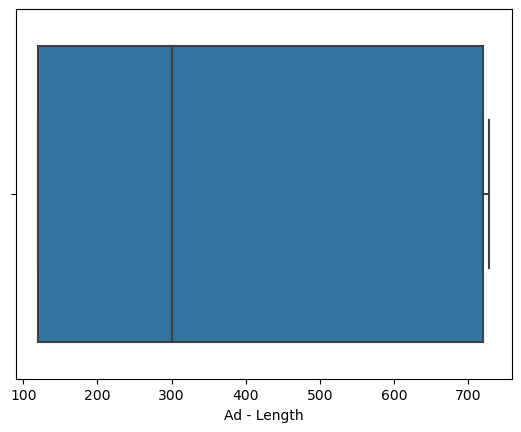

In [9]:
sns.boxplot(data=clustering_df, x='Ad - Length')

### Boxplot of Ad Width

<Axes: xlabel='Ad- Width'>

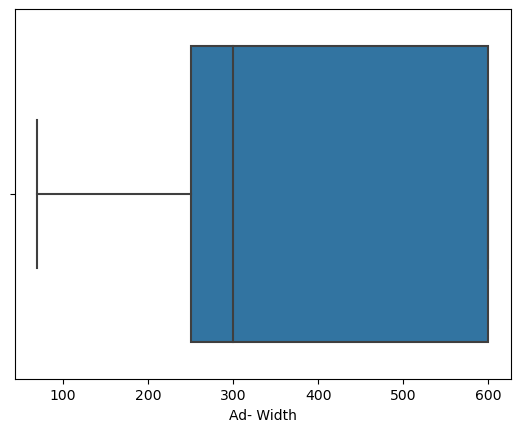

In [10]:
sns.boxplot(data=clustering_df, x='Ad- Width')

### Boxplot of Ad Size

<Axes: xlabel='Ad Size'>

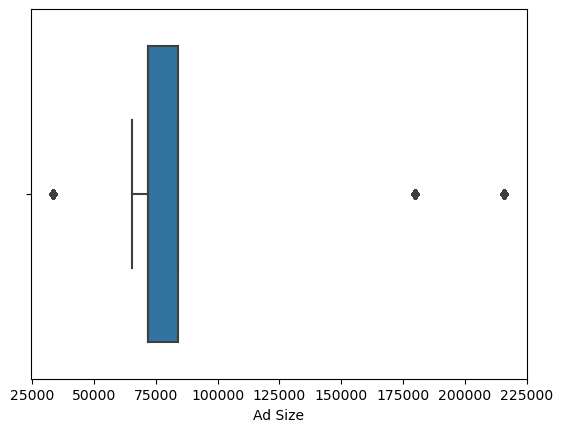

In [11]:
sns.boxplot(data=clustering_df, x='Ad Size')

### Boxplot of Available_Impressions

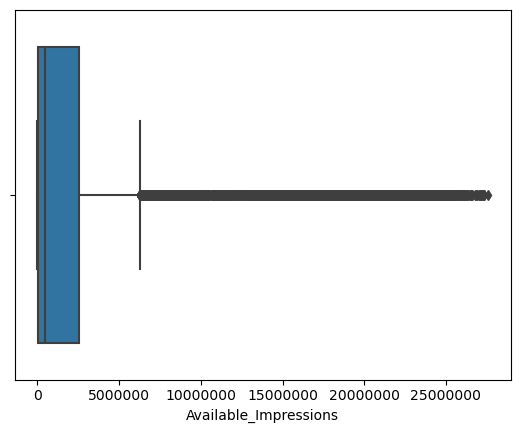

In [12]:
from  matplotlib.ticker import FuncFormatter
sns.boxplot(data=clustering_df, x='Available_Impressions')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))

<Axes: xlabel='Available_Impressions'>

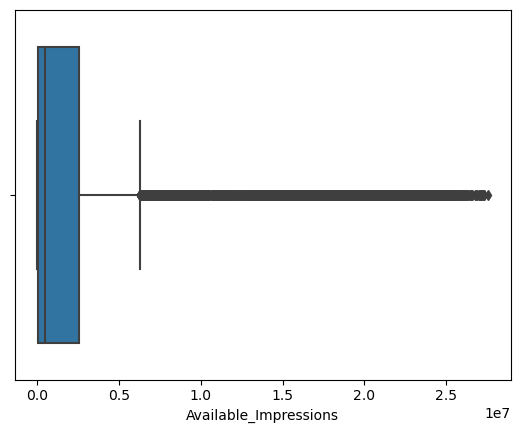

In [13]:
sns.boxplot(data=clustering_df, x='Available_Impressions')

In [14]:
clustering_df.Available_Impressions.unique()

array([1806, 1780, 2727, ...,  135,  379,  114], dtype=int64)

In [15]:
clustering_df.Available_Impressions.max()

27592861

### Boxplot of Matched_Queries

<Axes: xlabel='Matched_Queries'>

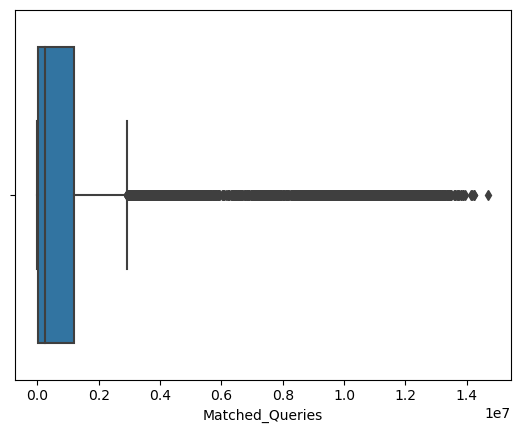

In [16]:
sns.boxplot(data=clustering_df, x='Matched_Queries')

In [17]:
clustering_df.Matched_Queries.max()

14702025

### Boxplot of Impressions

<Axes: xlabel='Impressions'>

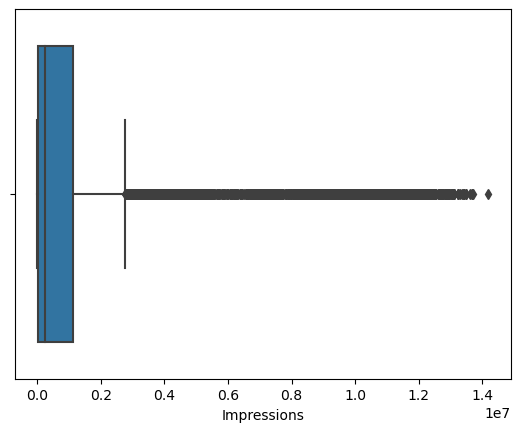

In [18]:
sns.boxplot(data=clustering_df, x='Impressions')

In [19]:
clustering_df.Impressions.max()

14194774

### Boxplot of Clicks

<Axes: xlabel='Clicks'>

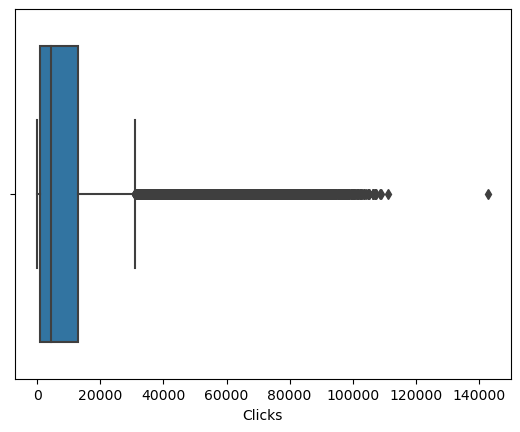

In [20]:
sns.boxplot(data=clustering_df, x='Clicks')

### Boxplot of Spend

<Axes: xlabel='Spend'>

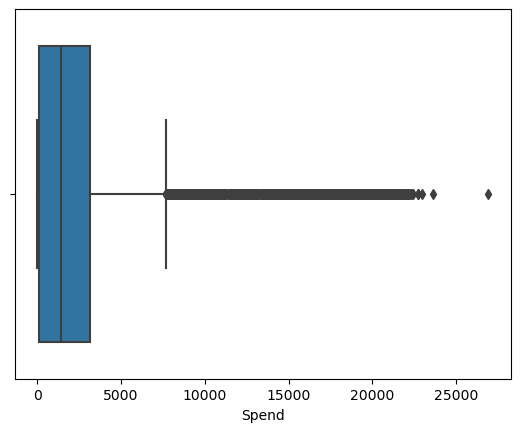

In [21]:
sns.boxplot(data=clustering_df, x='Spend')

### Boxplot of Fee

<Axes: xlabel='Fee'>

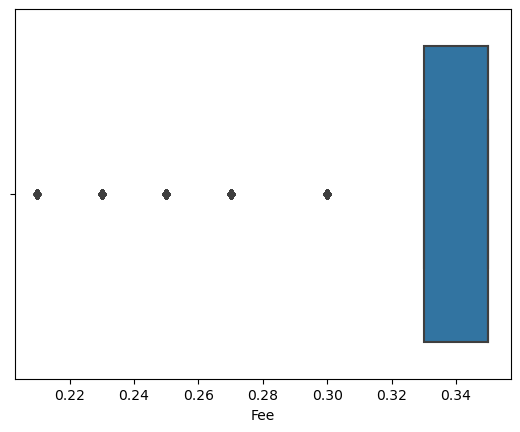

In [22]:
sns.boxplot(data=clustering_df, x='Fee')

In [23]:
clustering_df.Fee.min()

0.21

### Boxplot of Revenue

<Axes: xlabel='Revenue'>

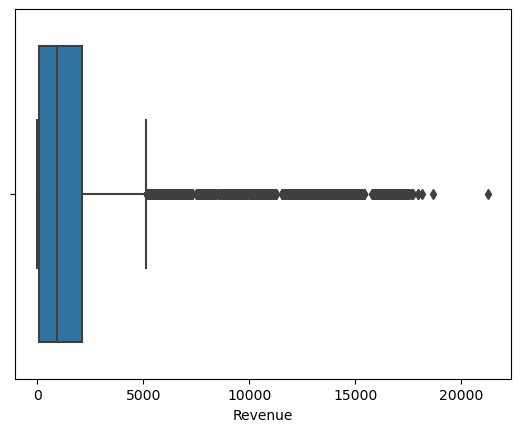

In [24]:
sns.boxplot(data=clustering_df, x='Revenue')

### Boxplot of CTR

<Axes: xlabel='CTR'>

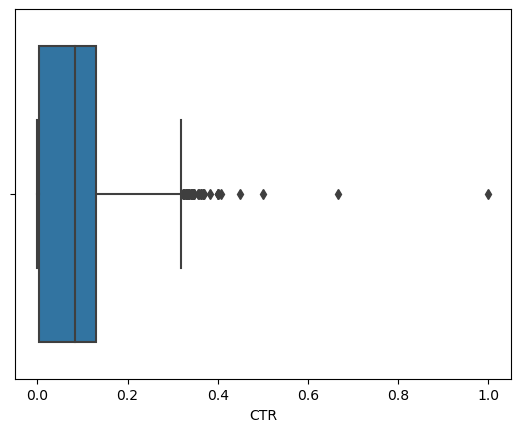

In [25]:
sns.boxplot(data=clustering_df, x='CTR')

### Boxplot of CPM

<Axes: xlabel='CPM'>

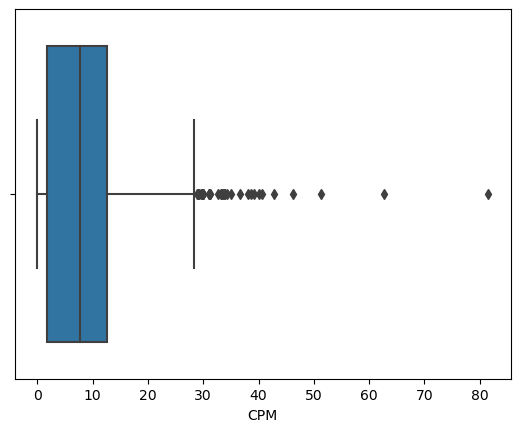

In [26]:
sns.boxplot(data=clustering_df, x='CPM')

### Boxplot of CPC

<Axes: xlabel='CPC'>

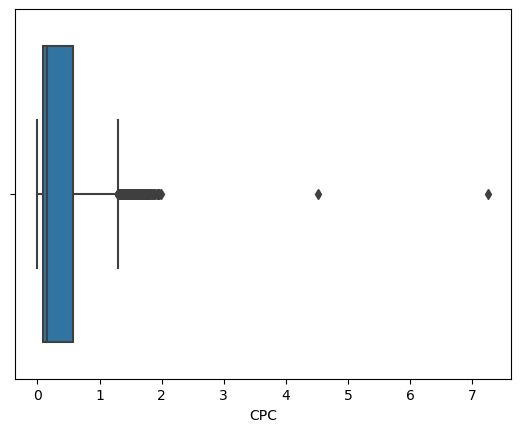

In [27]:
sns.boxplot(data=clustering_df, x='CPC')

#### CountPlot of InventoryType

<Axes: xlabel='InventoryType', ylabel='count'>

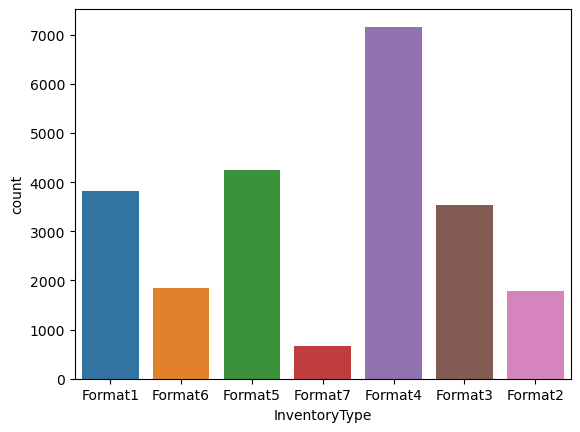

In [28]:
sns.countplot(data=clustering_df, x='InventoryType')

#### CountPlot of Ad Type

<Axes: xlabel='Ad Type', ylabel='count'>

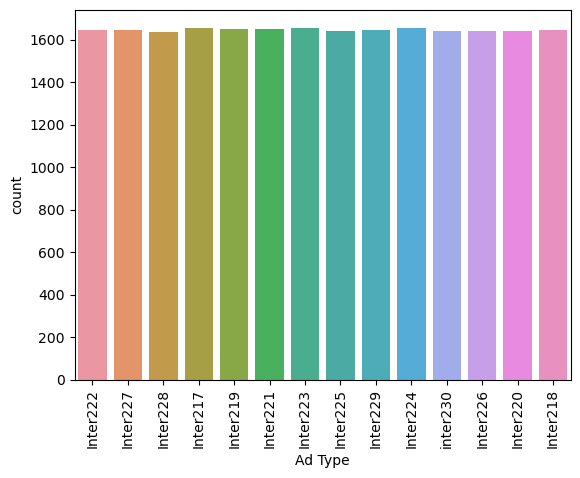

In [29]:
plt.xticks(rotation=90)
sns.countplot(data=clustering_df, x='Ad Type')

#### CountPlot of Platform

<Axes: xlabel='Platform', ylabel='count'>

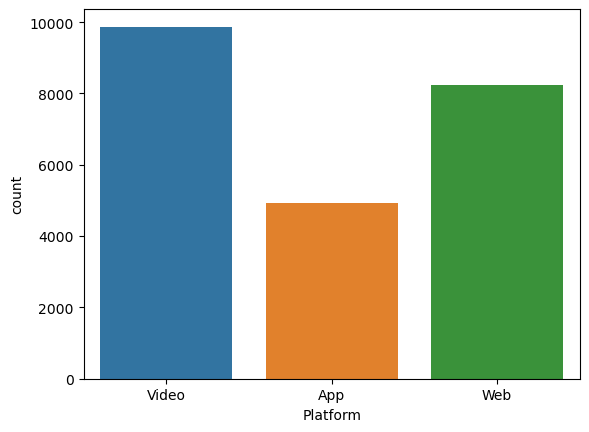

In [30]:
sns.countplot(data=clustering_df, x='Platform')

#### CountPlot of Device Type

<Axes: xlabel='Device Type', ylabel='count'>

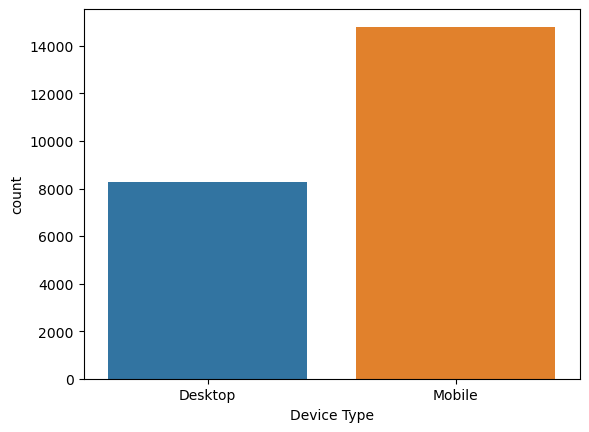

In [31]:
sns.countplot(data=clustering_df, x='Device Type')

#### CountPlot of Format

<Axes: xlabel='Format', ylabel='count'>

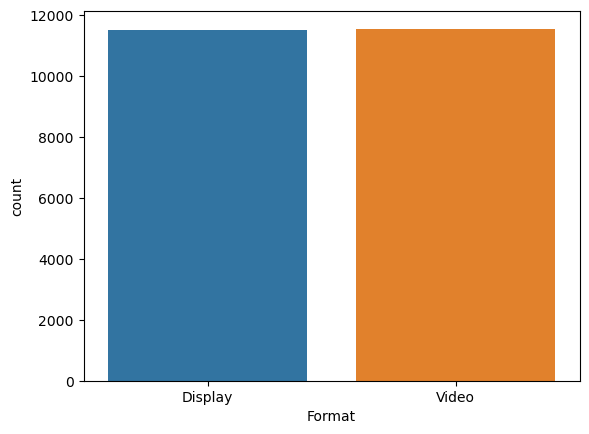

In [32]:
sns.countplot(data=clustering_df, x='Format')

### Bivariate Analysis

<Axes: xlabel='InventoryType', ylabel='Ad - Length'>

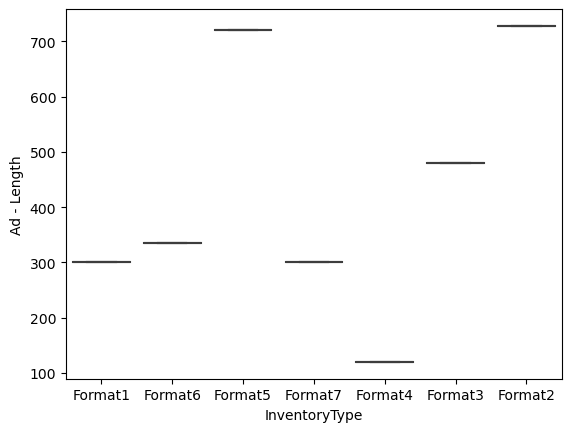

In [33]:
sns.boxplot(x='InventoryType', y='Ad - Length', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='Ad- Width'>

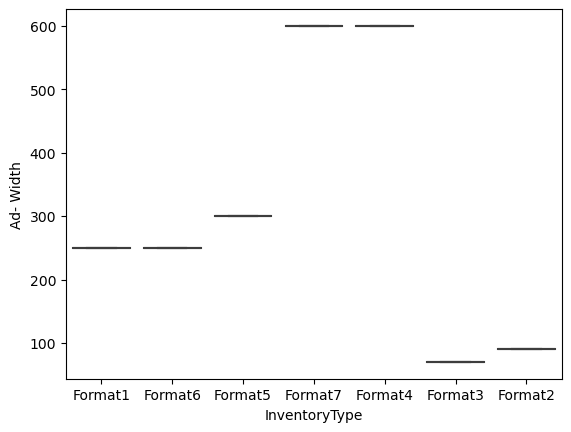

In [34]:
sns.boxplot(x='InventoryType', y='Ad- Width', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='Ad Size'>

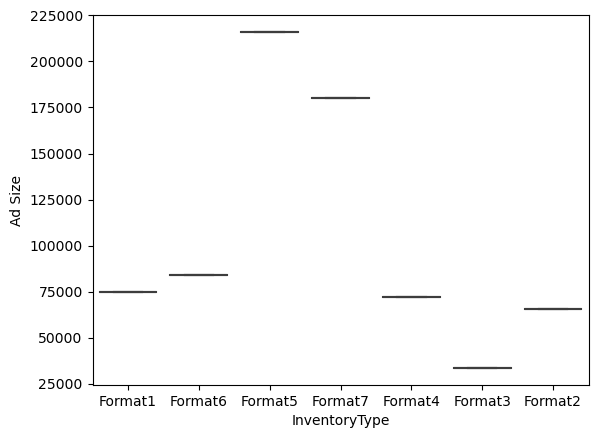

In [35]:
sns.boxplot(x='InventoryType', y='Ad Size', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='Available_Impressions'>

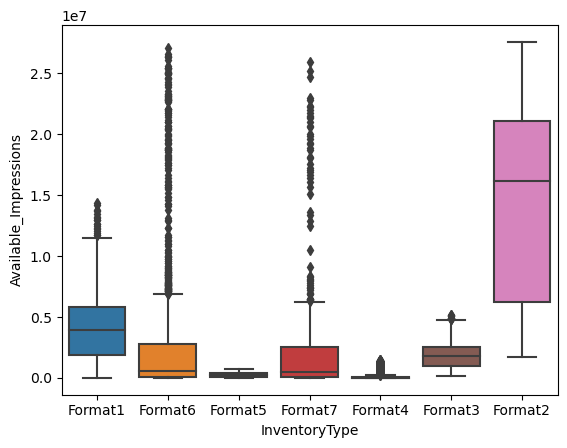

In [36]:
sns.boxplot(x='InventoryType', y='Available_Impressions', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='Matched_Queries'>

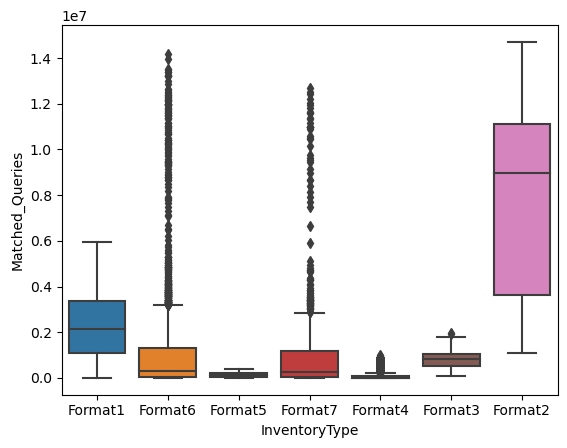

In [37]:
sns.boxplot(x='InventoryType', y='Matched_Queries', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='Impressions'>

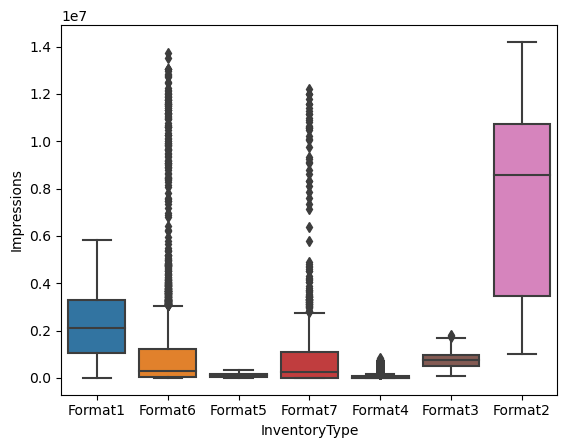

In [38]:
sns.boxplot(x='InventoryType', y='Impressions', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='Clicks'>

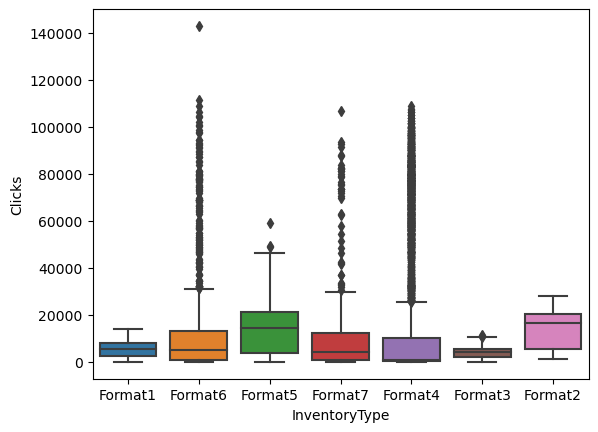

In [39]:
sns.boxplot(x='InventoryType', y='Clicks', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='Spend'>

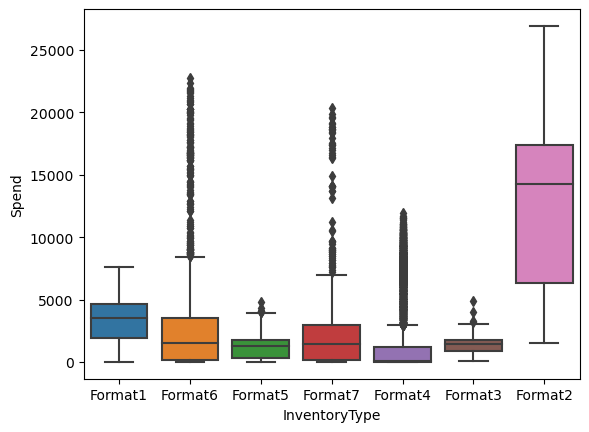

In [40]:
sns.boxplot(x='InventoryType', y='Spend', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='Fee'>

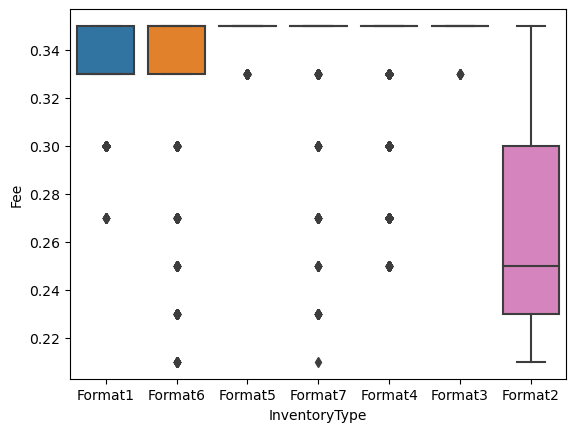

In [41]:
sns.boxplot(x='InventoryType', y='Fee', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='Revenue'>

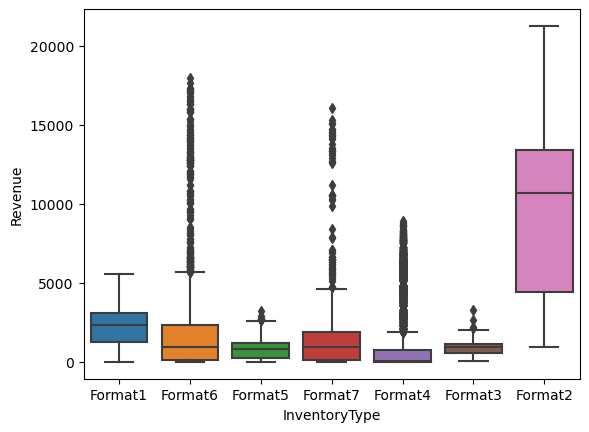

In [42]:
sns.boxplot(x='InventoryType', y='Revenue', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='CTR'>

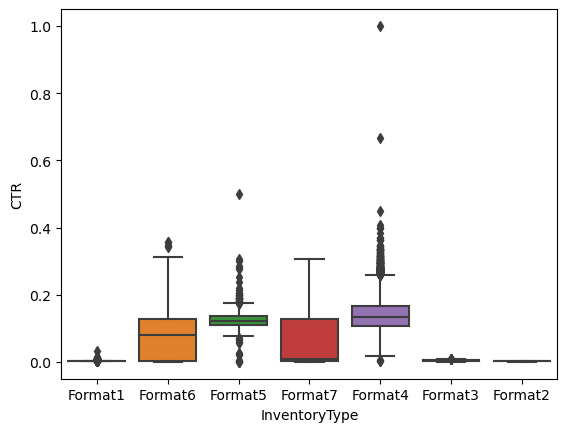

In [43]:
sns.boxplot(x='InventoryType', y='CTR', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='CPM'>

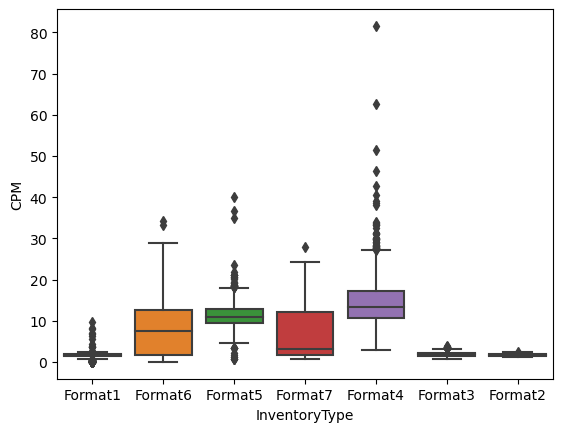

In [44]:
sns.boxplot(x='InventoryType', y='CPM', data=clustering_df)

<Axes: xlabel='InventoryType', ylabel='CPC'>

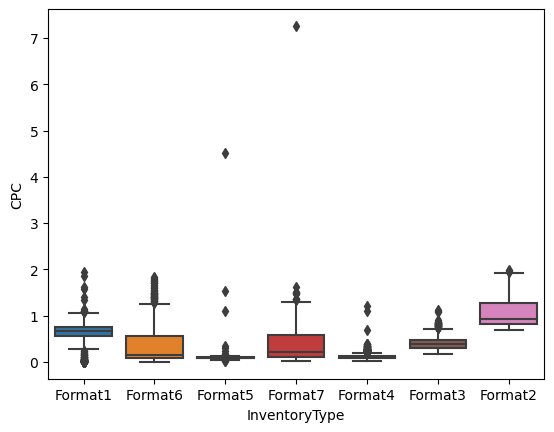

In [45]:
sns.boxplot(x='InventoryType', y='CPC', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='Ad - Length'>

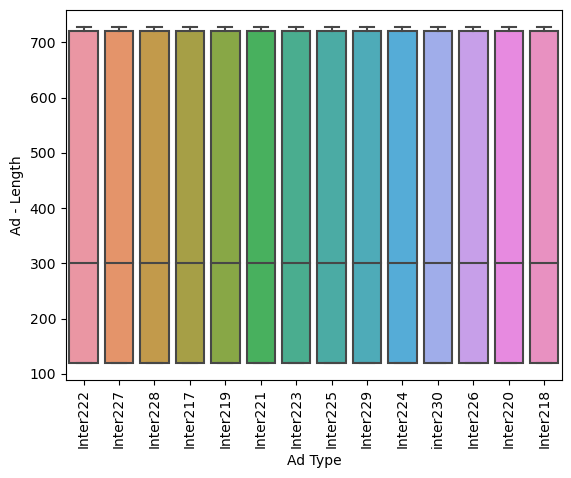

In [46]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='Ad - Length', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='Ad- Width'>

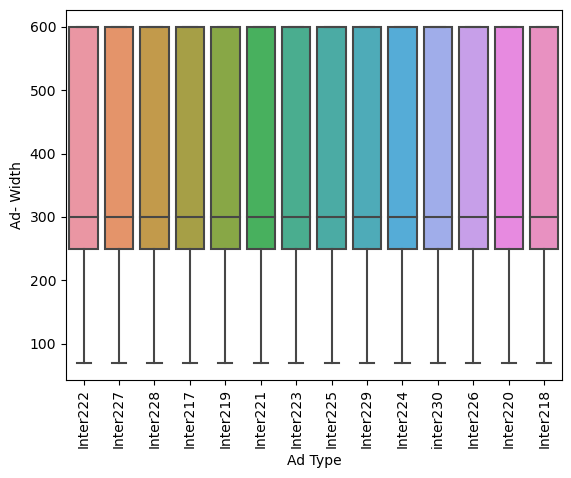

In [47]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='Ad- Width', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='Ad Size'>

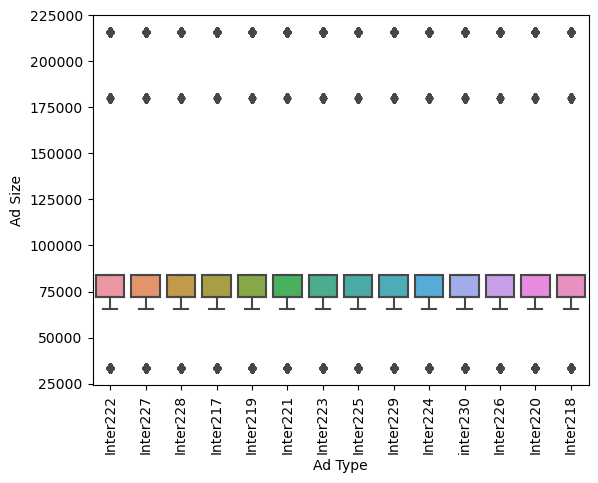

In [48]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='Ad Size', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='Available_Impressions'>

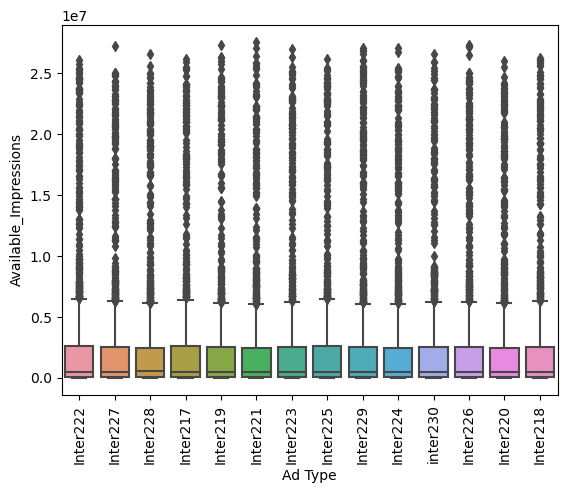

In [49]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='Available_Impressions', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='Matched_Queries'>

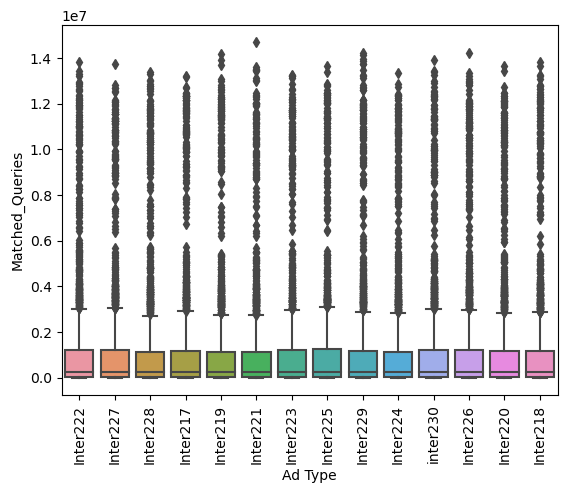

In [50]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='Matched_Queries', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='Impressions'>

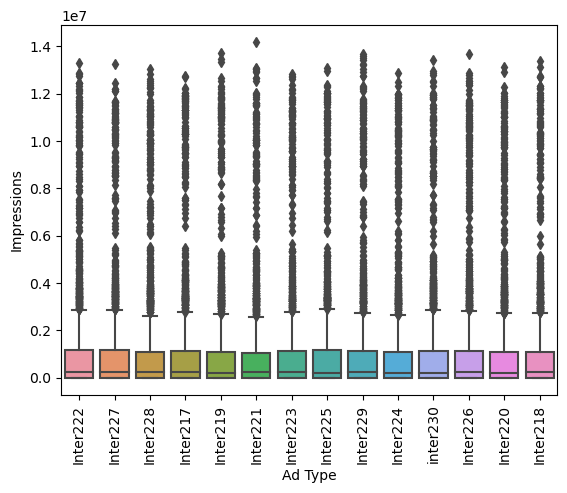

In [51]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='Impressions', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='Clicks'>

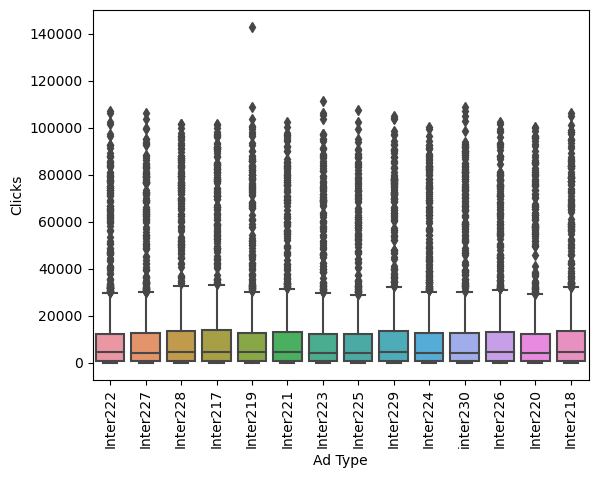

In [52]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='Clicks', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='Spend'>

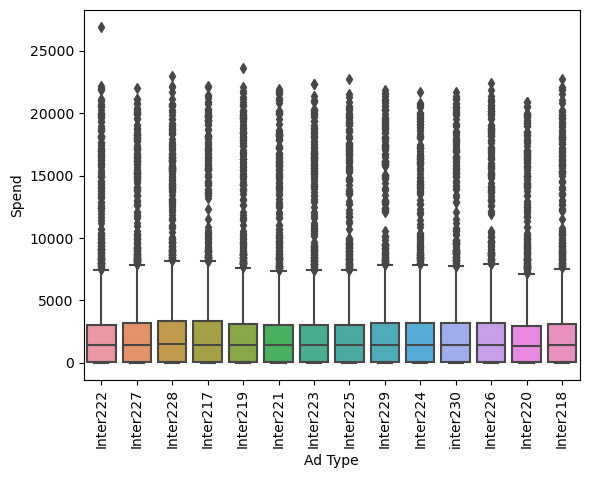

In [53]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='Spend', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='Fee'>

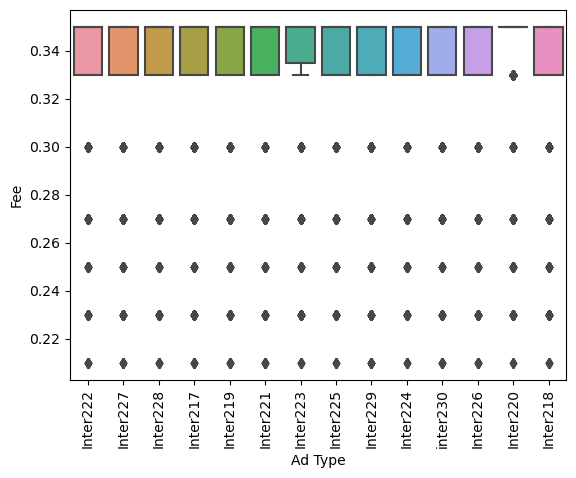

In [54]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='Fee', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='Revenue'>

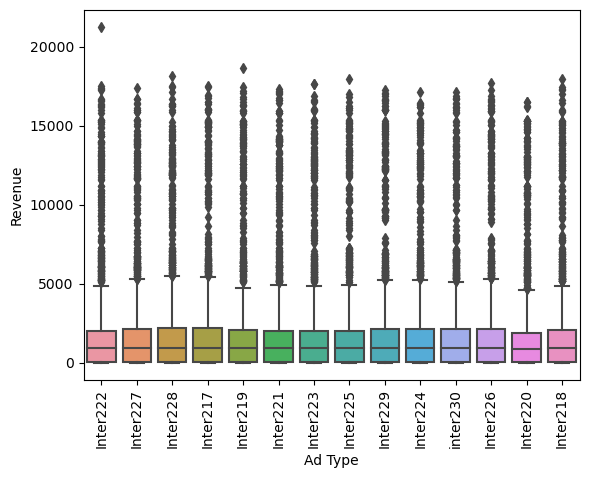

In [55]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='Revenue', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='CTR'>

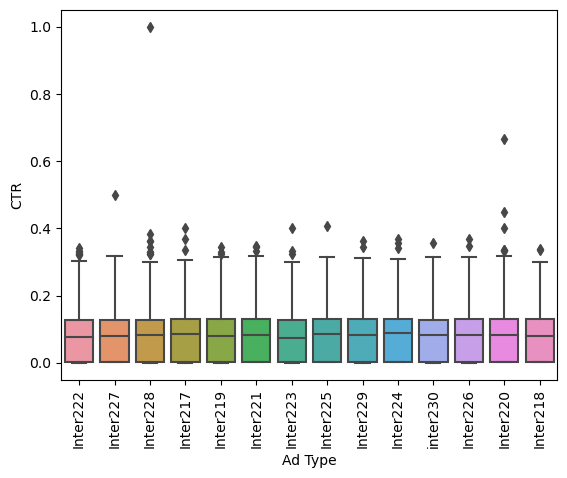

In [56]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='CTR', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='CPM'>

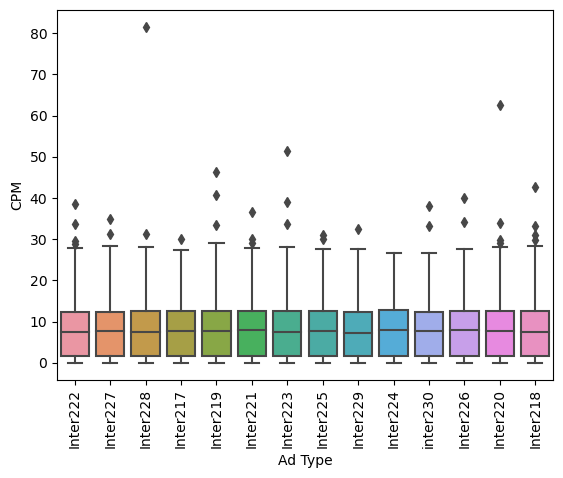

In [57]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='CPM', data=clustering_df)

<Axes: xlabel='Ad Type', ylabel='CPC'>

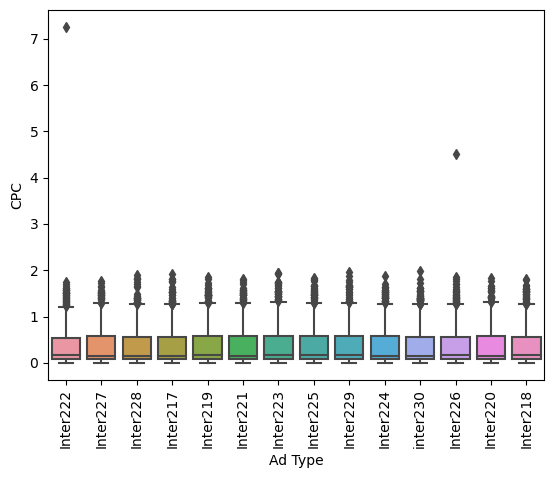

In [58]:
plt.xticks(rotation=90)
sns.boxplot(x='Ad Type', y='CPC', data=clustering_df)

<Axes: xlabel='Platform', ylabel='Ad - Length'>

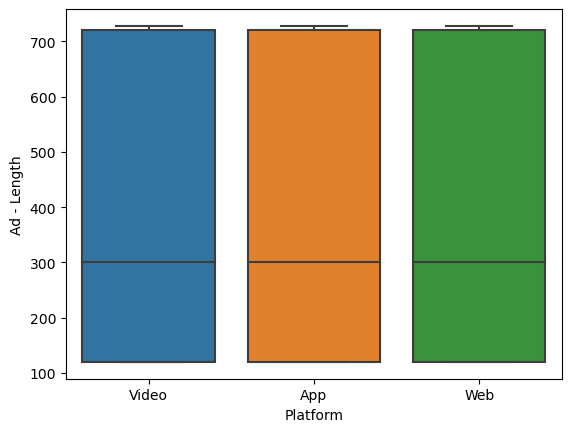

In [59]:
sns.boxplot(x='Platform', y='Ad - Length', data=clustering_df)

<Axes: xlabel='Platform', ylabel='Ad- Width'>

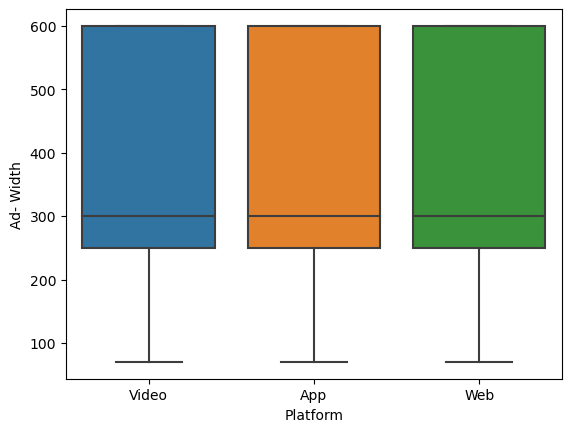

In [60]:
sns.boxplot(x='Platform', y='Ad- Width', data=clustering_df)

<Axes: xlabel='Platform', ylabel='Ad Size'>

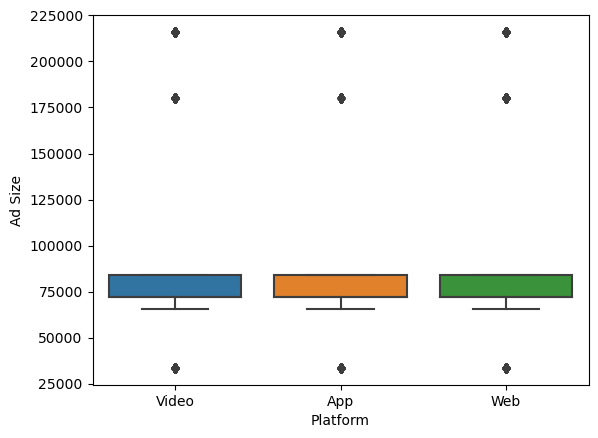

In [61]:
sns.boxplot(x='Platform', y='Ad Size', data=clustering_df)

<Axes: xlabel='Platform', ylabel='Available_Impressions'>

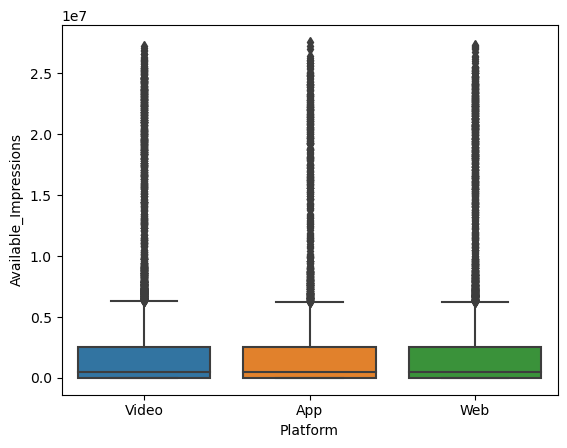

In [62]:
sns.boxplot(x='Platform', y='Available_Impressions', data=clustering_df)

<Axes: xlabel='Platform', ylabel='Matched_Queries'>

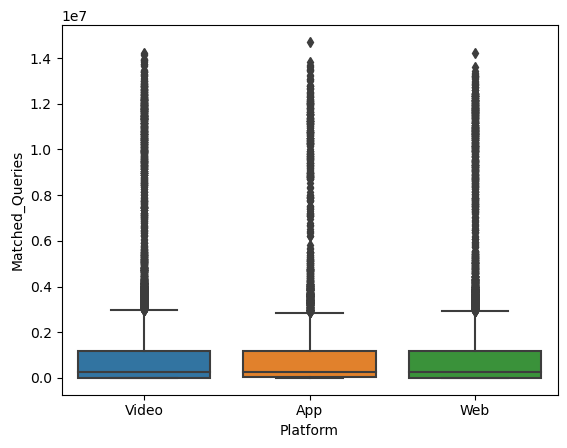

In [63]:
sns.boxplot(x='Platform', y='Matched_Queries', data=clustering_df)

<Axes: xlabel='Platform', ylabel='Impressions'>

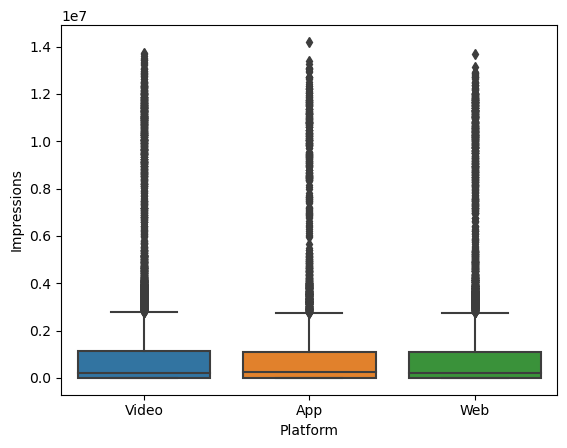

In [64]:
sns.boxplot(x='Platform', y='Impressions', data=clustering_df)

<Axes: xlabel='Platform', ylabel='Clicks'>

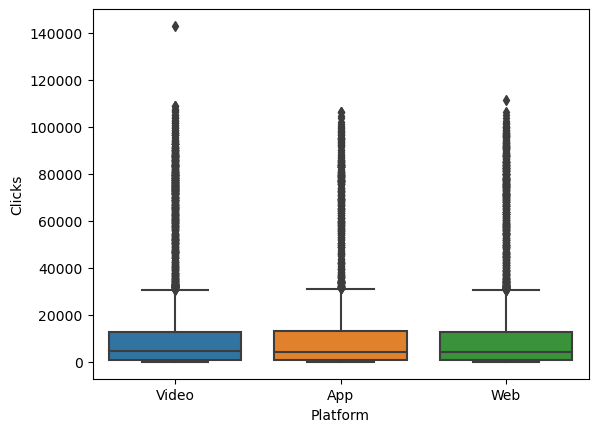

In [65]:
sns.boxplot(x='Platform', y='Clicks', data=clustering_df)

<Axes: xlabel='Platform', ylabel='Spend'>

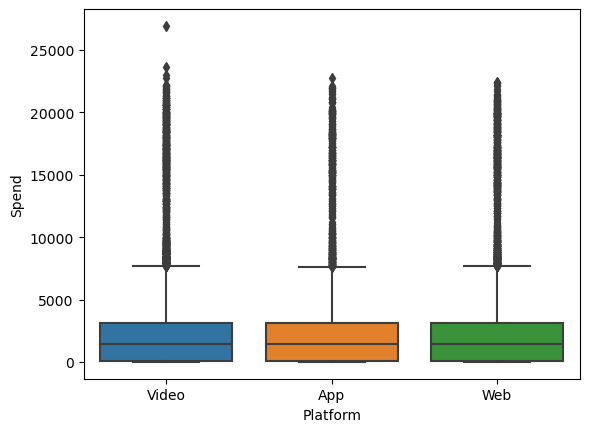

In [66]:
sns.boxplot(x='Platform', y='Spend', data=clustering_df)

<Axes: xlabel='Platform', ylabel='Fee'>

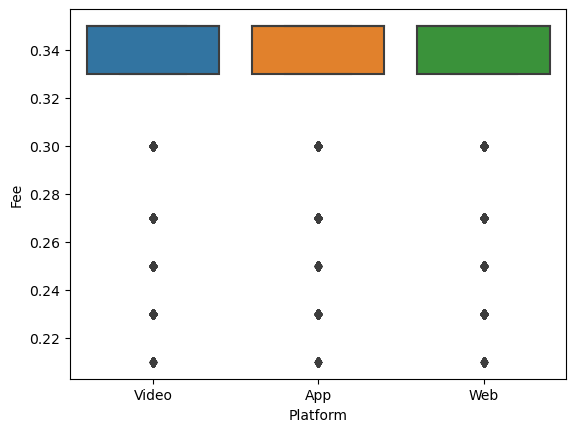

In [67]:
sns.boxplot(x='Platform', y='Fee', data=clustering_df)

<Axes: xlabel='Platform', ylabel='Revenue'>

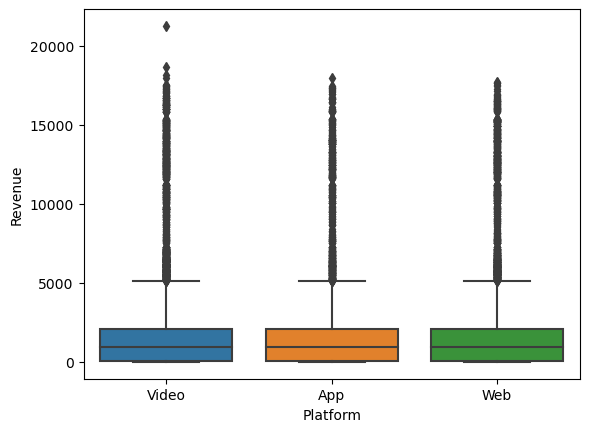

In [68]:
sns.boxplot(x='Platform', y='Revenue', data=clustering_df)

<Axes: xlabel='Platform', ylabel='CTR'>

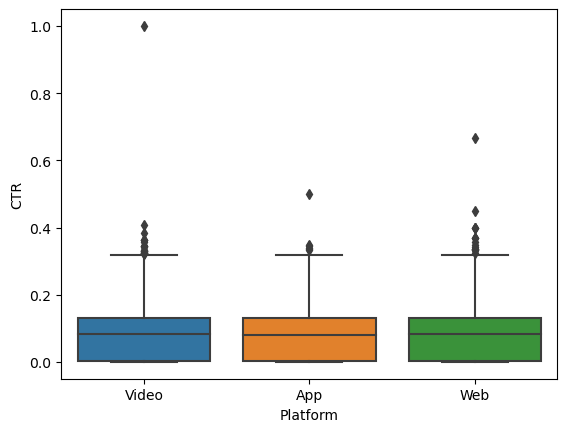

In [69]:
sns.boxplot(x='Platform', y='CTR', data=clustering_df)

<Axes: xlabel='Platform', ylabel='CPM'>

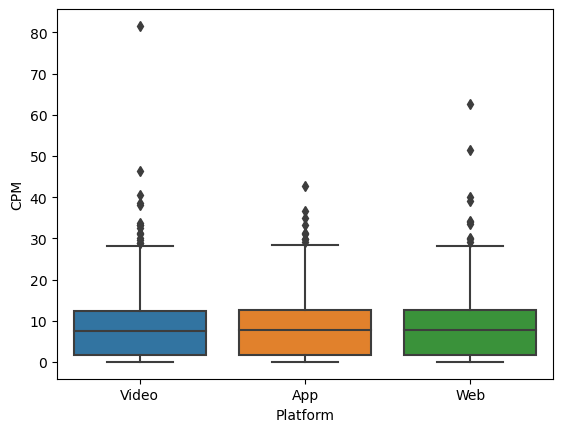

In [70]:
sns.boxplot(x='Platform', y='CPM', data=clustering_df)

<Axes: xlabel='Platform', ylabel='CPC'>

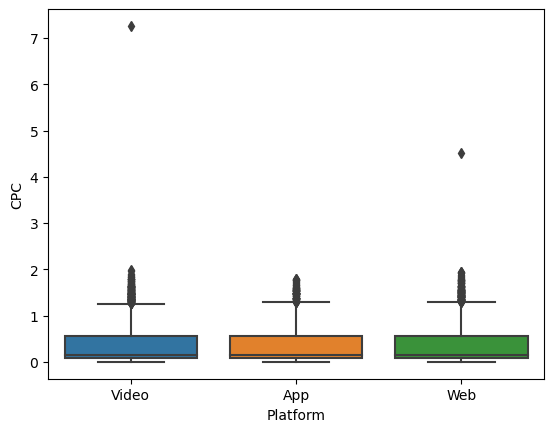

In [71]:
sns.boxplot(x='Platform', y='CPC', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='Ad - Length'>

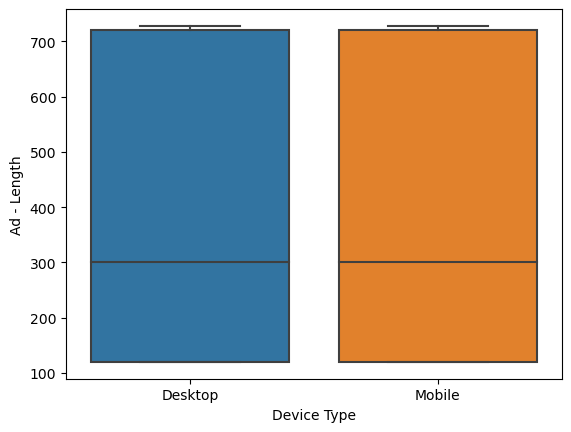

In [72]:
sns.boxplot(x='Device Type', y='Ad - Length', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='Ad- Width'>

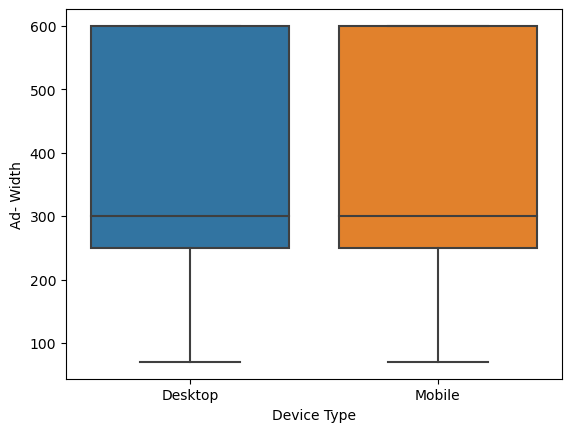

In [73]:
sns.boxplot(x='Device Type', y='Ad- Width', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='Ad Size'>

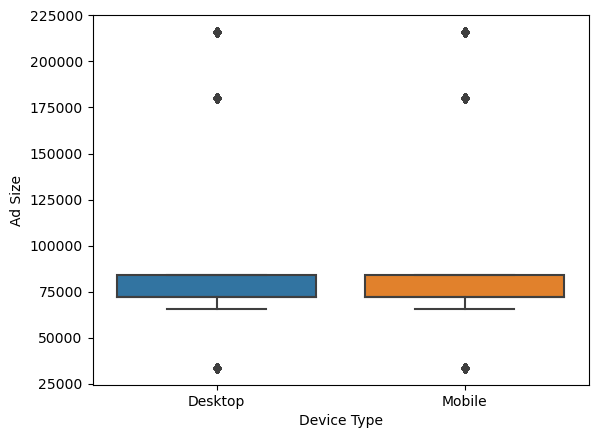

In [74]:
sns.boxplot(x='Device Type', y='Ad Size', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='Available_Impressions'>

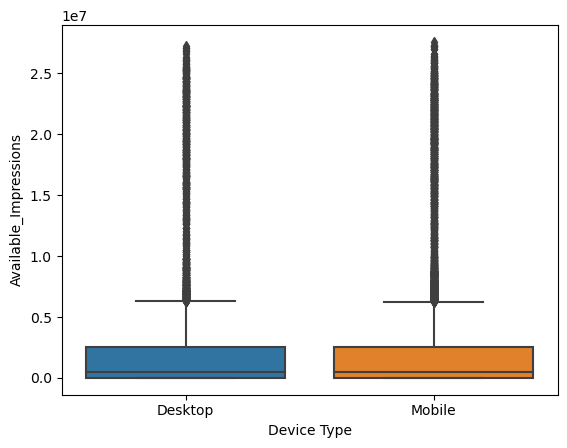

In [75]:
sns.boxplot(x='Device Type', y='Available_Impressions', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='Matched_Queries'>

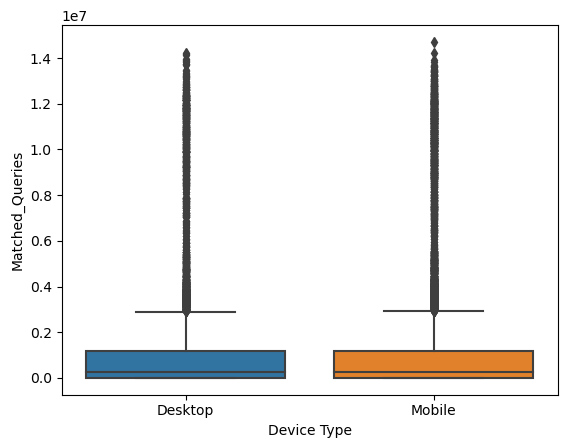

In [76]:
sns.boxplot(x='Device Type', y='Matched_Queries', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='Impressions'>

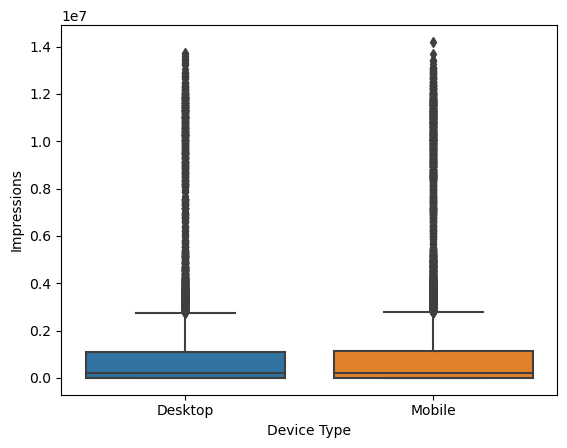

In [77]:
sns.boxplot(x='Device Type', y='Impressions', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='Clicks'>

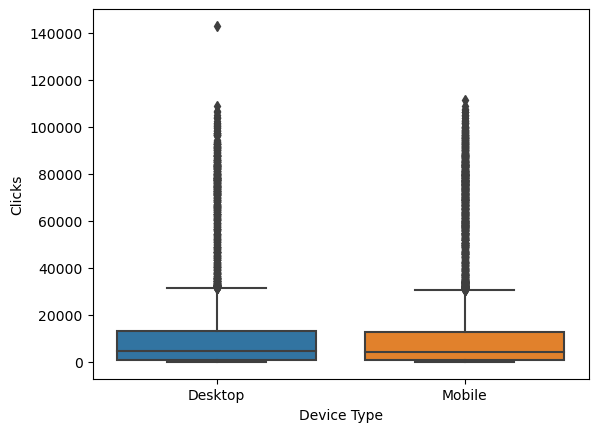

In [78]:
sns.boxplot(x='Device Type', y='Clicks', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='Spend'>

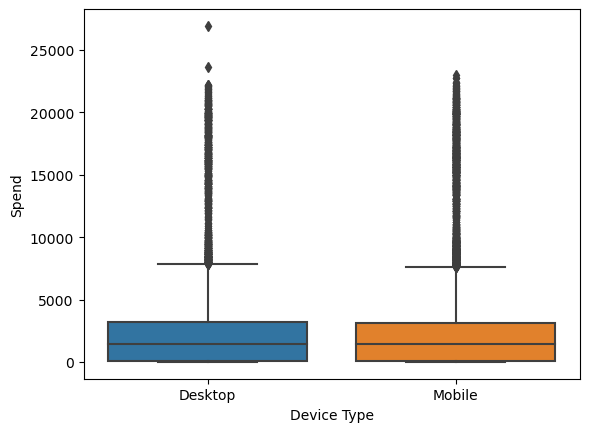

In [79]:
sns.boxplot(x='Device Type', y='Spend', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='Fee'>

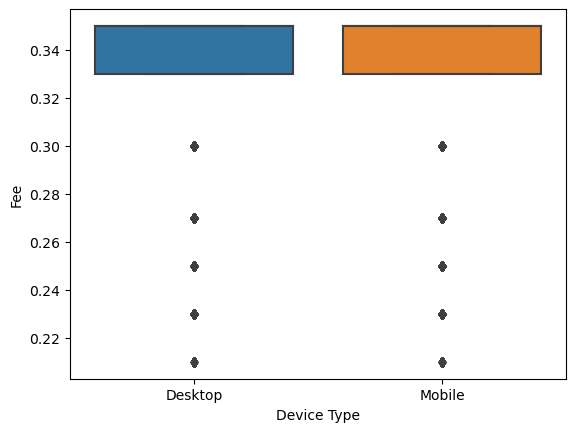

In [80]:
sns.boxplot(x='Device Type', y='Fee', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='Revenue'>

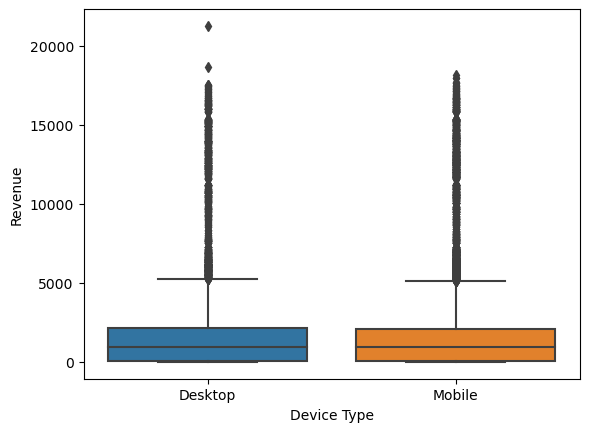

In [81]:
sns.boxplot(x='Device Type', y='Revenue', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='CTR'>

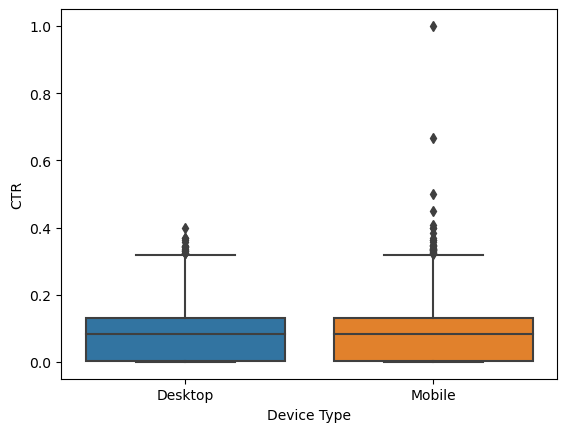

In [82]:
sns.boxplot(x='Device Type', y='CTR', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='CPM'>

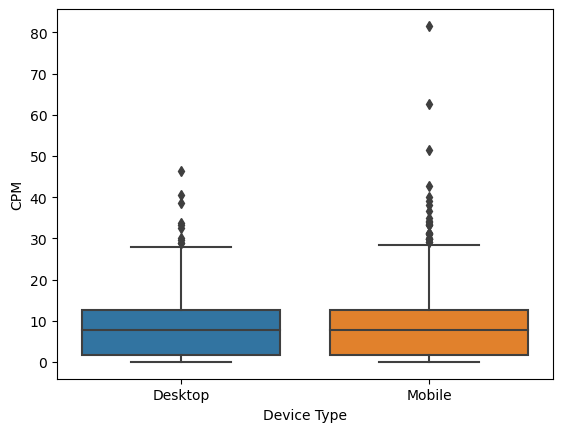

In [83]:
sns.boxplot(x='Device Type', y='CPM', data=clustering_df)

<Axes: xlabel='Device Type', ylabel='CPC'>

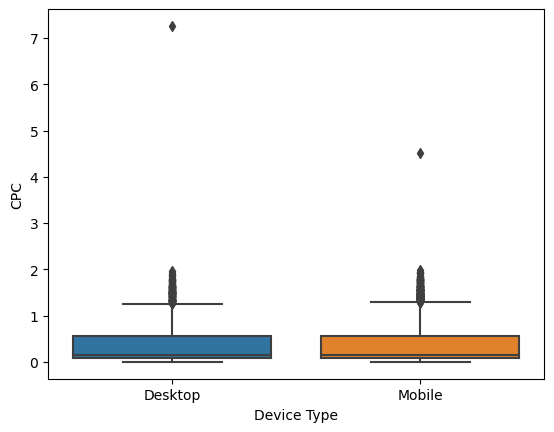

In [84]:
sns.boxplot(x='Device Type', y='CPC', data=clustering_df)

<Axes: xlabel='Format', ylabel='Ad - Length'>

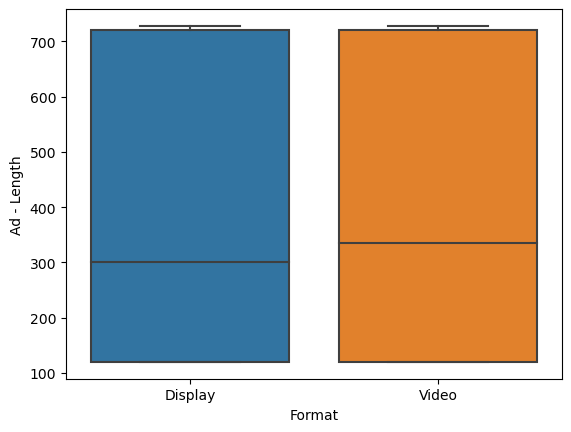

In [85]:
sns.boxplot(x='Format', y='Ad - Length', data=clustering_df)

<Axes: xlabel='Format', ylabel='Ad- Width'>

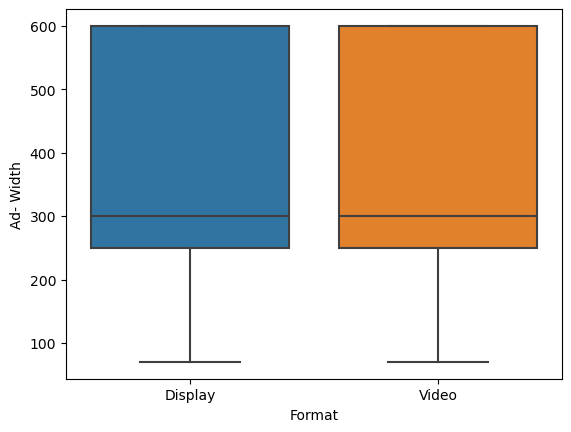

In [86]:
sns.boxplot(x='Format', y='Ad- Width', data=clustering_df)

<Axes: xlabel='Format', ylabel='Ad Size'>

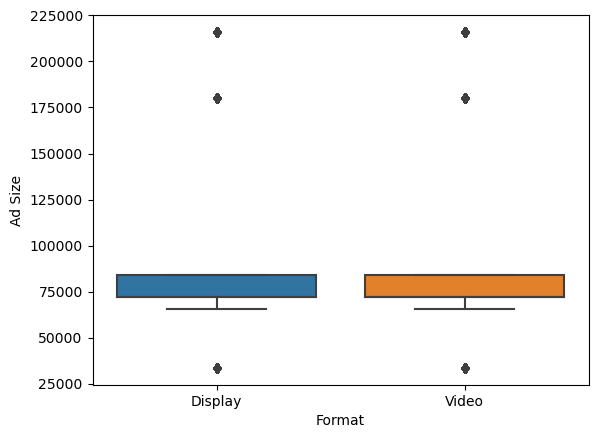

In [87]:
sns.boxplot(x='Format', y='Ad Size', data=clustering_df)

<Axes: xlabel='Format', ylabel='Available_Impressions'>

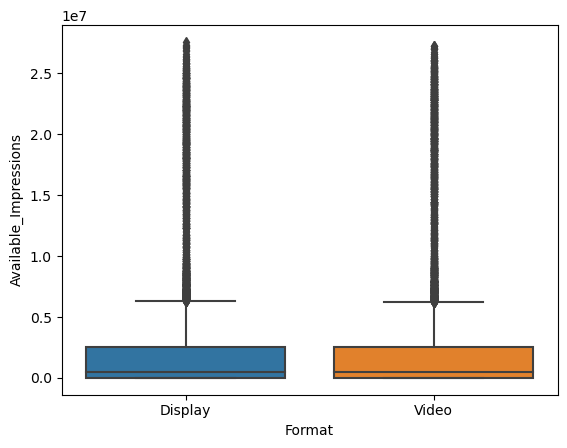

In [88]:
sns.boxplot(x='Format', y='Available_Impressions', data=clustering_df)

<Axes: xlabel='Format', ylabel='Matched_Queries'>

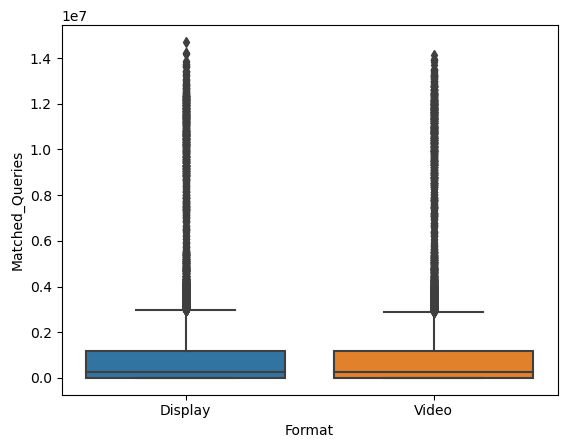

In [89]:
sns.boxplot(x='Format', y='Matched_Queries', data=clustering_df)

<Axes: xlabel='Format', ylabel='Impressions'>

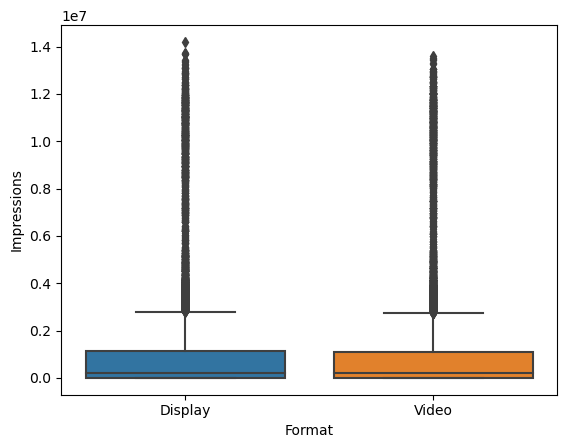

In [90]:
sns.boxplot(x='Format', y='Impressions', data=clustering_df)

<Axes: xlabel='Format', ylabel='Clicks'>

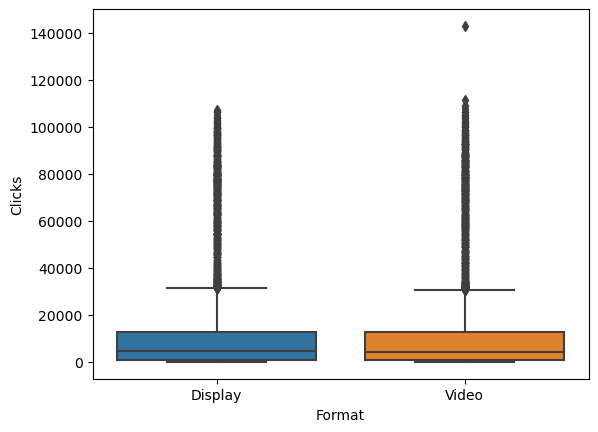

In [91]:
sns.boxplot(x='Format', y='Clicks', data=clustering_df)

<Axes: xlabel='Format', ylabel='Spend'>

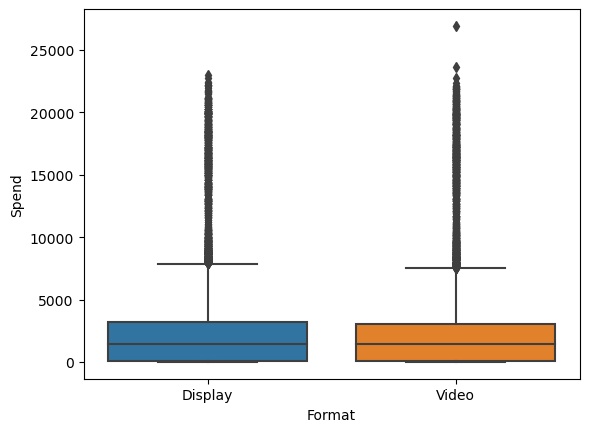

In [92]:
sns.boxplot(x='Format', y='Spend', data=clustering_df)

<Axes: xlabel='Format', ylabel='Fee'>

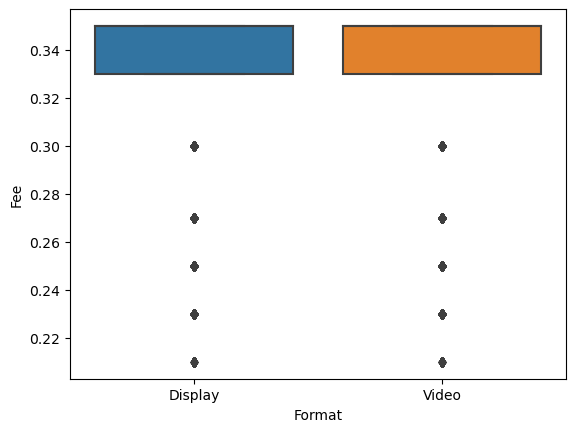

In [93]:
sns.boxplot(x='Format', y='Fee', data=clustering_df)

<Axes: xlabel='Format', ylabel='Revenue'>

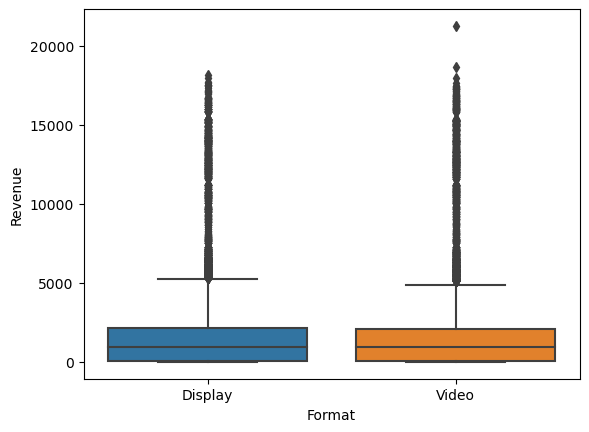

In [94]:
sns.boxplot(x='Format', y='Revenue', data=clustering_df)

<Axes: xlabel='Format', ylabel='CTR'>

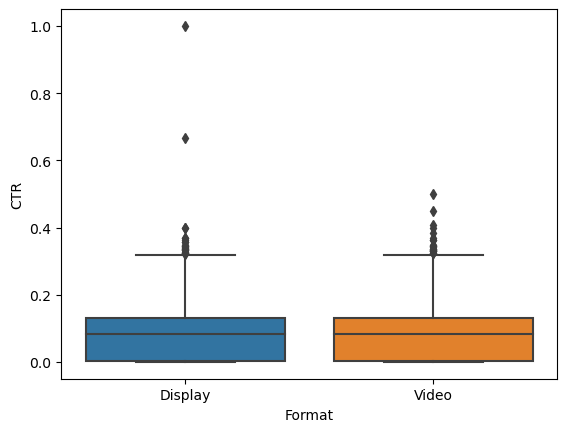

In [95]:
sns.boxplot(x='Format', y='CTR', data=clustering_df)

<Axes: xlabel='Format', ylabel='CPM'>

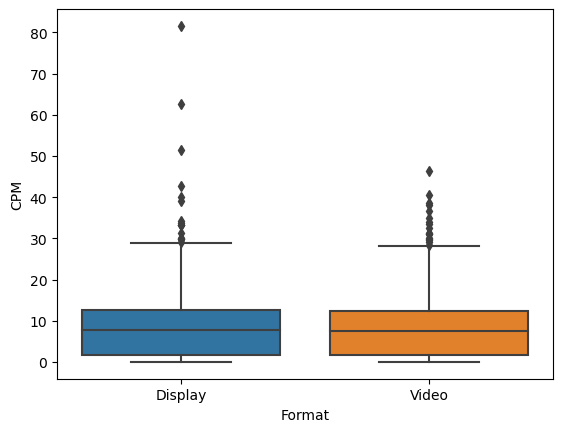

In [96]:
sns.boxplot(x='Format', y='CPM', data=clustering_df)

<Axes: xlabel='Format', ylabel='CPC'>

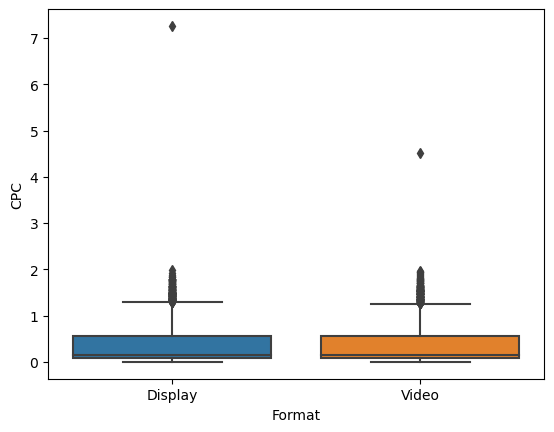

In [97]:
sns.boxplot(x='Format', y='CPC', data=clustering_df)

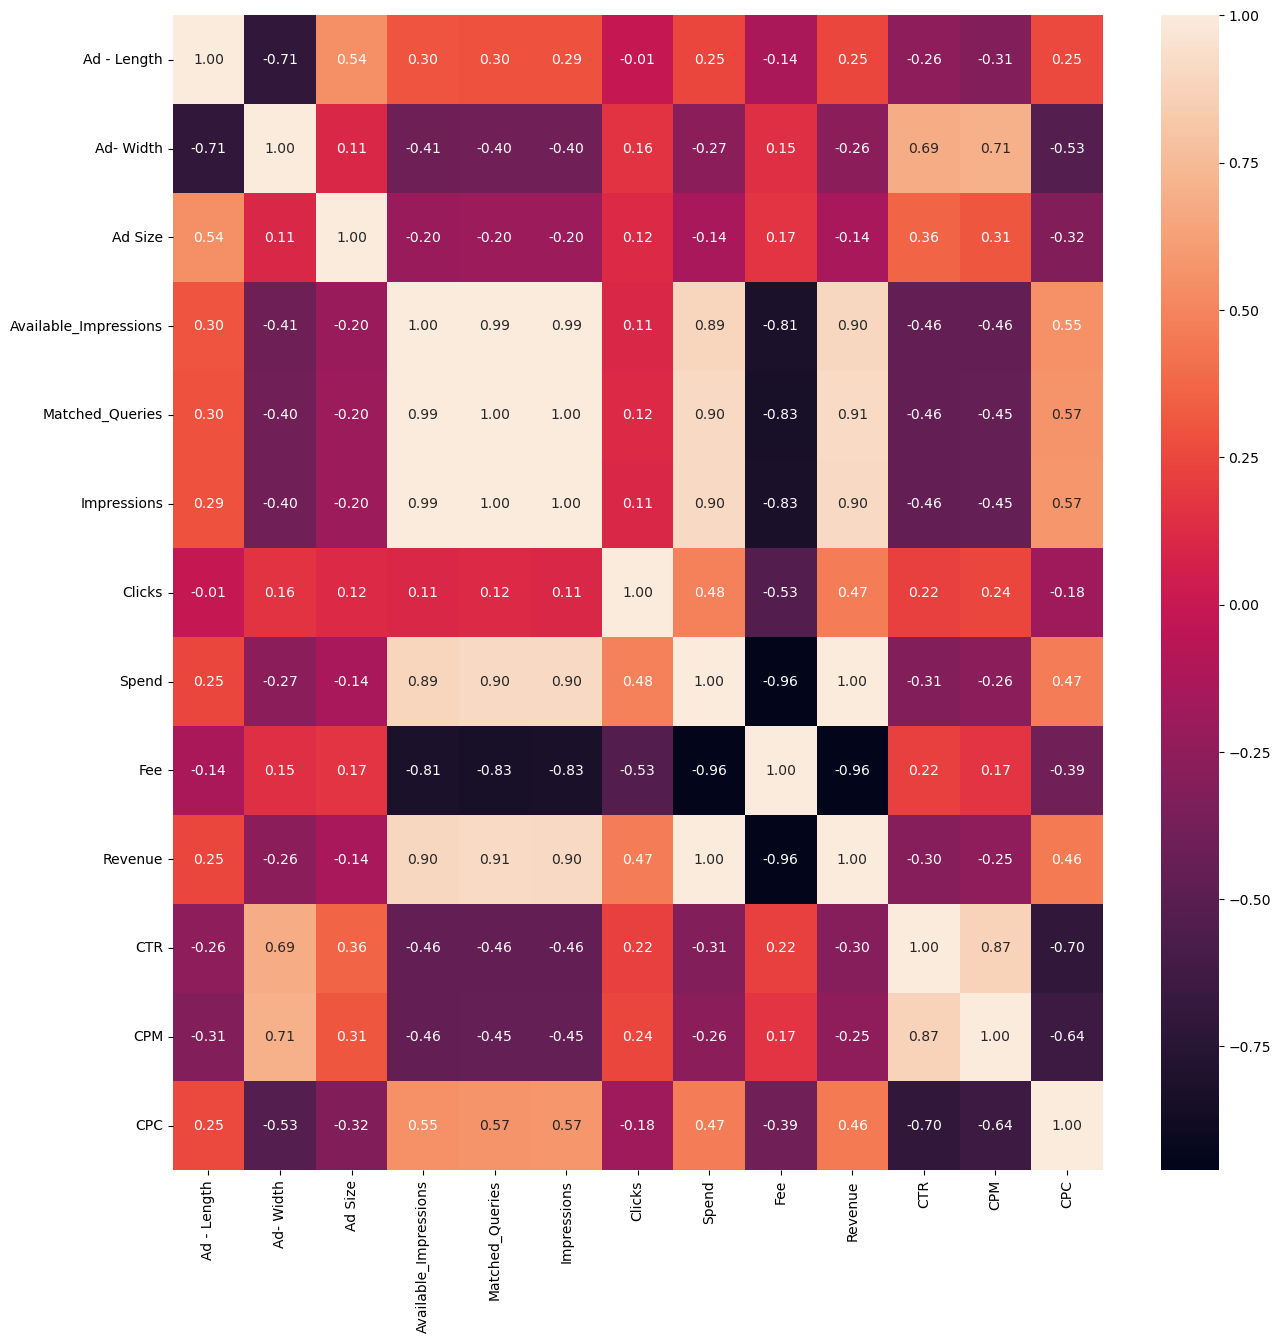

In [98]:
#### Correlation between Numerical Variables

plt.figure(figsize=(15,15))


df= clustering_df[['Ad - Length','Ad- Width','Ad Size','Available_Impressions','Matched_Queries','Impressions','Clicks','Spend','Fee','Revenue','CTR','CPM','CPC']]
sns.heatmap(df.corr(),annot=True,fmt=".2f");

C:\Users\Vijay\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


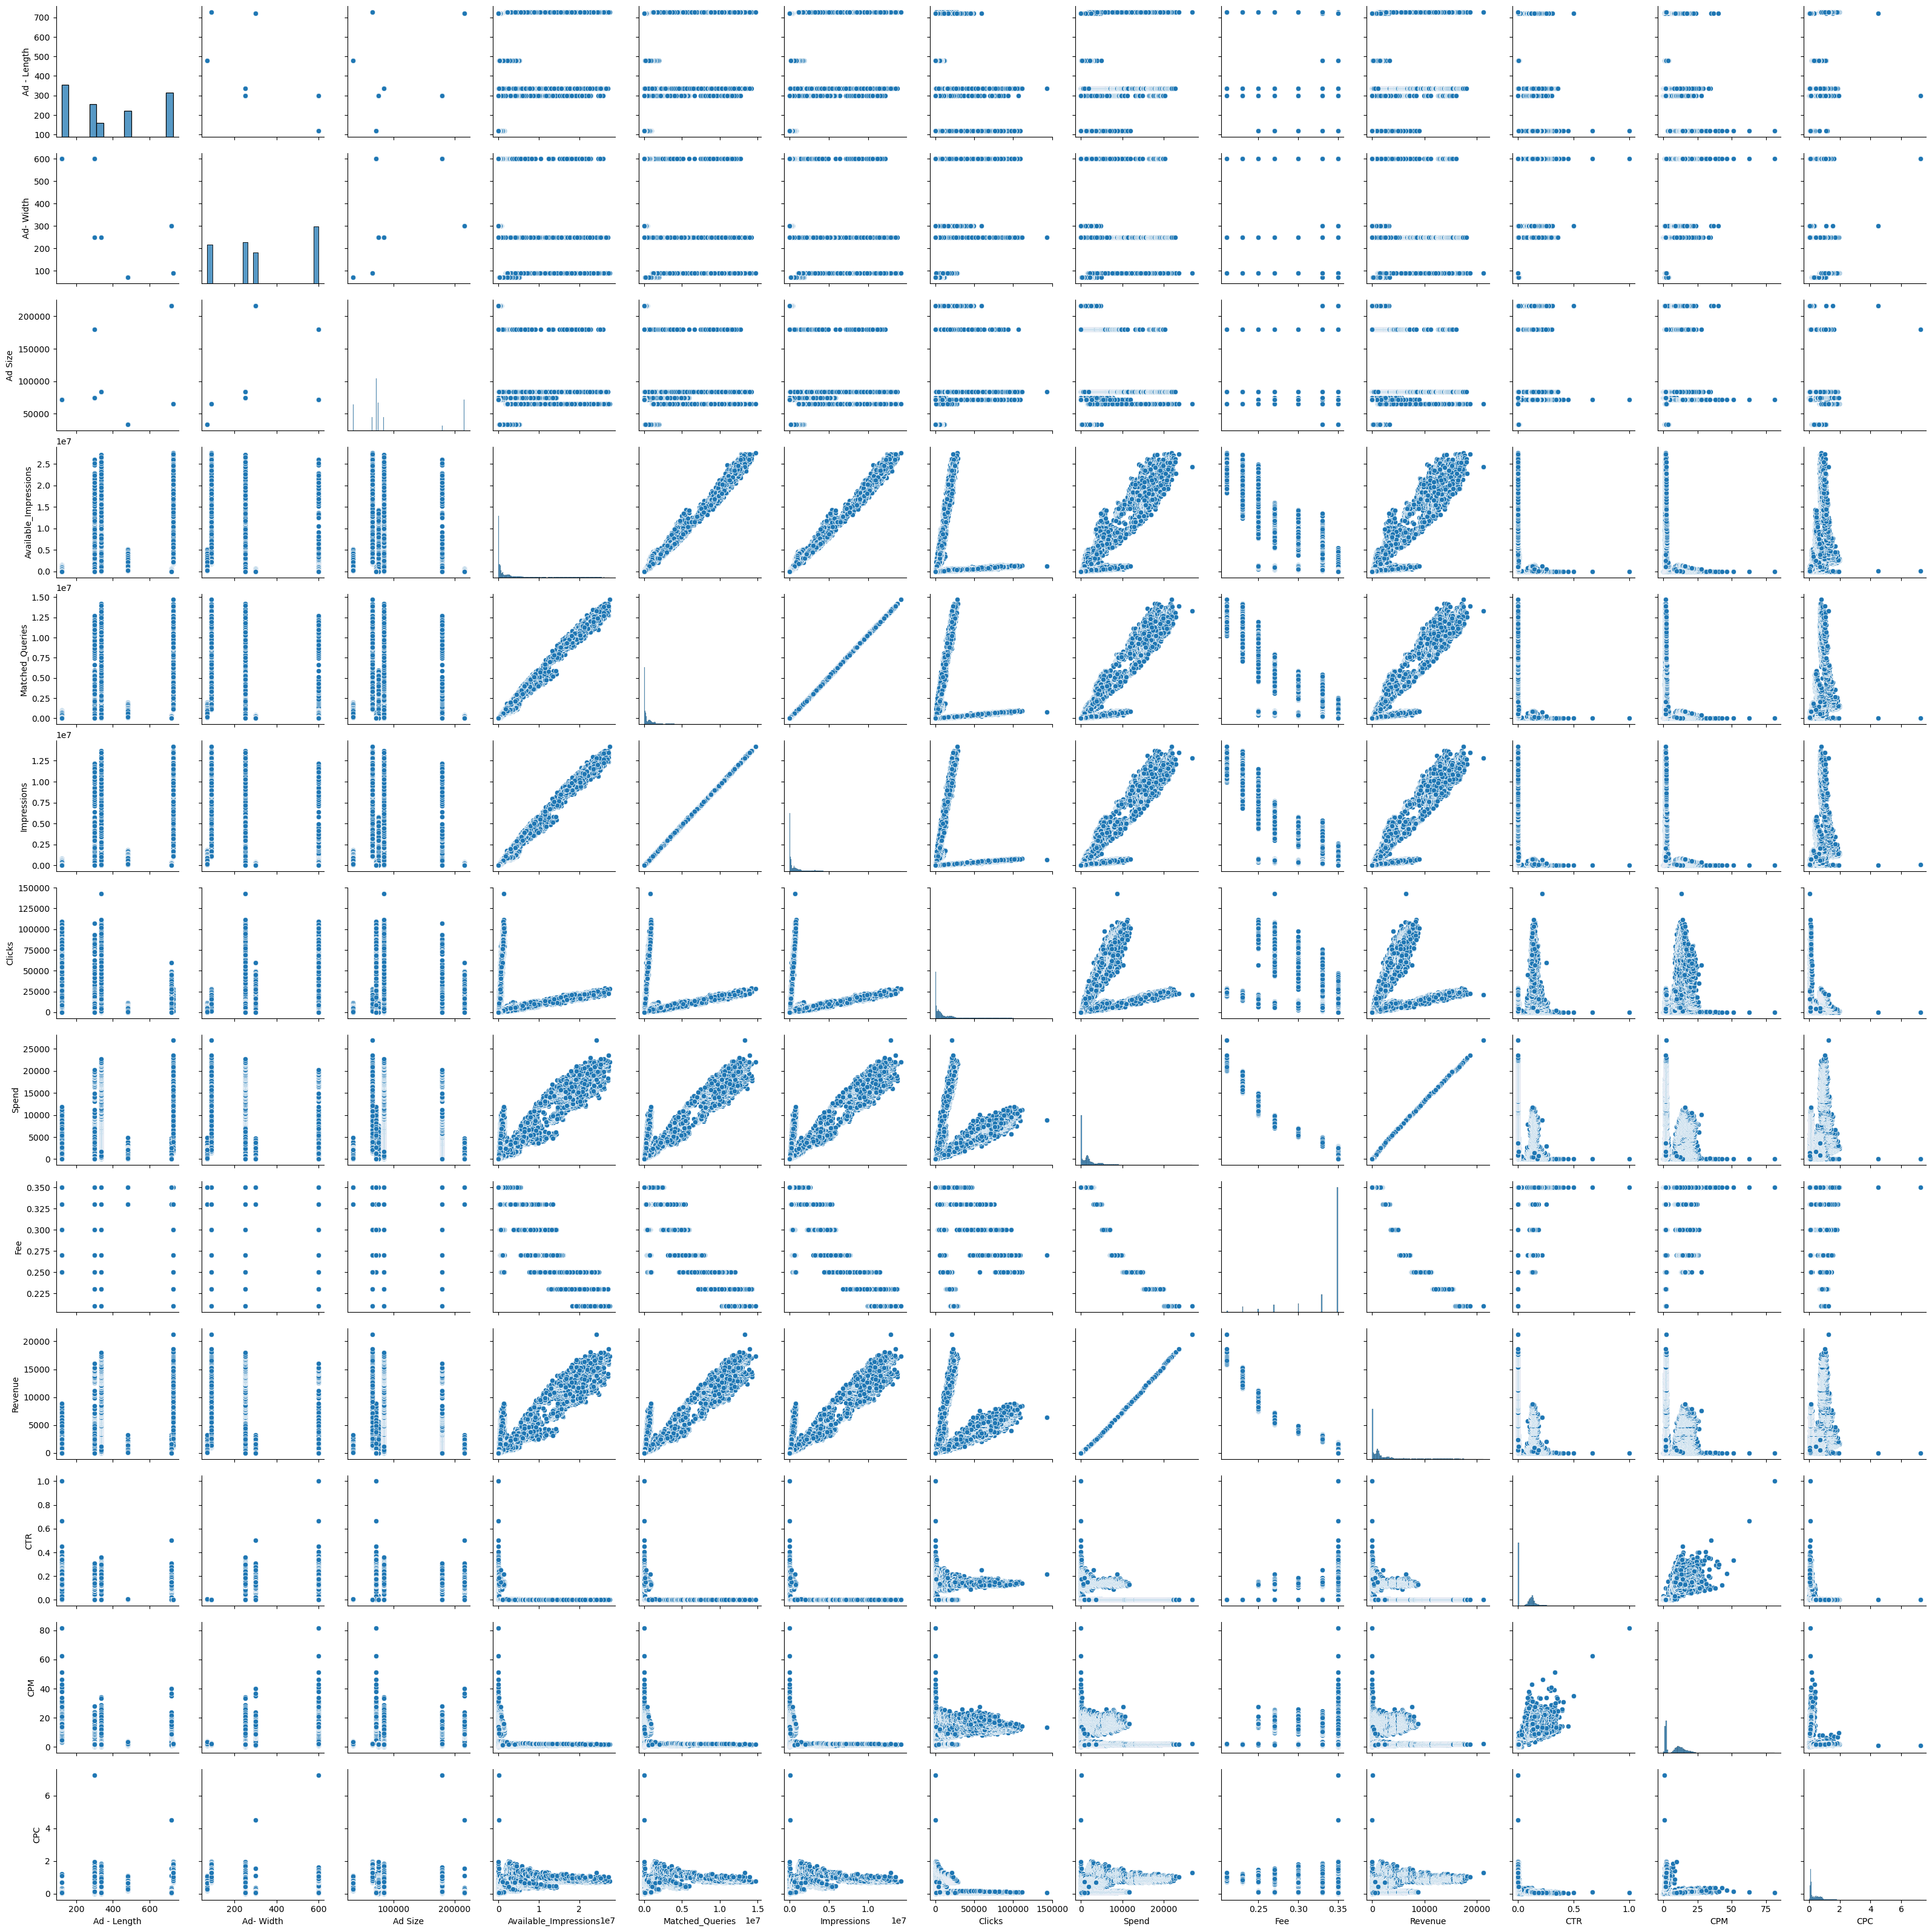

In [99]:
sns.pairplot(data=df)

### Formula Based Technique to treat missing values

#### CPM = (Total Campaign Spend / Number of Impressions) * 1,000.

In [100]:
def calculate_cpm(x):
    spend=clustering_df.Spend
    impressions=clustering_df.Impressions
    CPM = (spend/impressions)*1000
    return CPM

#### CPC = Total Cost (spend) / Number of Clicks.

In [101]:
def calculate_cpc(x):
    spend=clustering_df.Spend
    Clicks=clustering_df.Clicks
    CPC = (spend/Clicks)
    return CPC

#### CTR = Total Measured Clicks / Total Measured Ad Impressions x 100

In [102]:
def calculate_ctr(x):
    Clicks=clustering_df.Clicks
    impressions=clustering_df.Impressions
    CTR = (Clicks/impressions)*100
    return CTR

In [103]:
clustering_df['CPM']= clustering_df[['CPM']].apply(lambda x: calculate_cpm(x))

In [104]:
clustering_df['CPC']= clustering_df[['CPC']].apply(lambda x: calculate_cpc(x))

In [105]:
clustering_df['CTR']= clustering_df[['CTR']].apply(lambda x: calculate_ctr(x))

In [106]:
clustering_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23066 entries, 0 to 23065
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Timestamp              23066 non-null  object 
 1   InventoryType          23066 non-null  object 
 2   Ad - Length            23066 non-null  int64  
 3   Ad- Width              23066 non-null  int64  
 4   Ad Size                23066 non-null  int64  
 5   Ad Type                23066 non-null  object 
 6   Platform               23066 non-null  object 
 7   Device Type            23066 non-null  object 
 8   Format                 23066 non-null  object 
 9   Available_Impressions  23066 non-null  int64  
 10  Matched_Queries        23066 non-null  int64  
 11  Impressions            23066 non-null  int64  
 12  Clicks                 23066 non-null  int64  
 13  Spend                  23066 non-null  float64
 14  Fee                    23066 non-null  float64
 15  Re

In [107]:
clustering_df.describe()

,Ad - Length,Ad- Width,Ad Size,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
count,23066.000000,23066.000000,23066.000000,2.306600e+04,2.306600e+04,2.306600e+04,23066.000000,23066.000000,23066.000000,23066.000000,23066.000000,23066.000000,23066.000000
mean,385.163097,337.896037,96674.468048,2.432044e+06,1.295099e+06,1.241520e+06,10678.518816,2706.625689,0.335123,1924.252331,8.409941,8.396849,0.336678
std,233.651434,203.092885,61538.329557,4.742888e+06,2.512970e+06,2.429400e+06,17353.409363,4067.927273,0.031963,3105.238410,9.262048,9.057760,0.341253
min,120.000000,70.000000,33600.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000,0.210000,0.000000,0.010874,0.000000,0.000000
25%,120.000000,250.000000,72000.000000,3.367225e+04,1.828250e+04,7.990500e+03,710.000000,85.180000,0.330000,55.365375,0.265107,1.749084,0.089736
50%,300.000000,300.000000,72000.000000,4.837710e+05,2.580875e+05,2.252900e+05,4425.000000,1425.125000,0.350000,926.335000,9.391248,8.371566,0.139347
75%,720.000000,600.000000,84000.000000,2.527712e+06,1.180700e+06,1.112428e+06,12793.750000,3121.400000,0.350000,2091.338150,13.470571,13.042018,0.546242
max,728.000000,600.000000,216000.000000,2.759286e+07,1.470202e+07,1.419477e+07,143049.000000,26931.870000,0.350000,21276.180000,200.000000,715.000000,7.264000


### Outlier Treatment

#### Chart before Treatment

<Axes: >

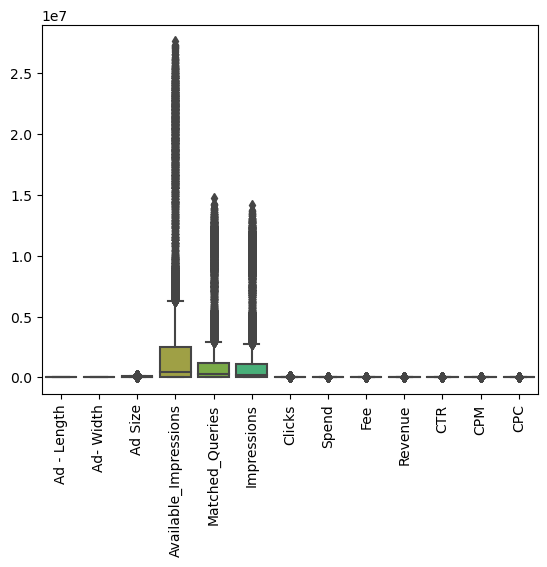

In [108]:
plt.xticks(rotation=90)
sns.boxplot(data=clustering_df)

In [109]:
clustering_df_num = clustering_df.select_dtypes(include = ['float64', 'int64'])
clustering_df_cat = clustering_df.select_dtypes(include = ['object'])

#### Number of Outliers in each Column

In [110]:
Q1 = clustering_df_num.quantile(0.25)
Q3 = clustering_df_num.quantile(0.75)
IQR = Q3 - Q1

In [111]:
# The count of outliers in each column
((clustering_df_num < (Q1 - 1.5 * IQR)) | (clustering_df_num > (Q3 + 1.5 * IQR))).sum()

Ad - Length                 0
Ad- Width                   0
Ad Size                  8448
Available_Impressions    2378
Matched_Queries          3192
Impressions              3269
Clicks                   1691
Spend                    2081
Fee                      3517
Revenue                  2325
CTR                       275
CPM                       207
CPC                       585
dtype: int64

In [112]:
no_outlier = ['Ad - Length','Ad- Width']

In [113]:
def treat_outlier(x):
    
    # taking 5,25,75 percentile of column
    q5= np.percentile(x,5)
    q25=np.percentile(x,25)
    q75=np.percentile(x,75)
    q95=np.percentile(x,95)
    #calculationg IQR range
    IQR=q75-q25
    #Calculating minimum threshold
    lower_bound=q25-(1.5*IQR)
    upper_bound=q75+(1.5*IQR)
    #Capping outliers
    return x.apply(lambda y: upper_bound if y > upper_bound else y).apply(lambda y: lower_bound if y < lower_bound else y)

In [114]:
outlier_list = [x for x in clustering_df_num.columns if x not in no_outlier]
outlier_list

['Ad Size',
 'Available_Impressions',
 'Matched_Queries',
 'Impressions',
 'Clicks',
 'Spend',
 'Fee',
 'Revenue',
 'CTR',
 'CPM',
 'CPC']

In [115]:
for i in clustering_df_num[outlier_list]: 
    clustering_df_num[i]=treat_outlier(clustering_df_num[i])

<Axes: >

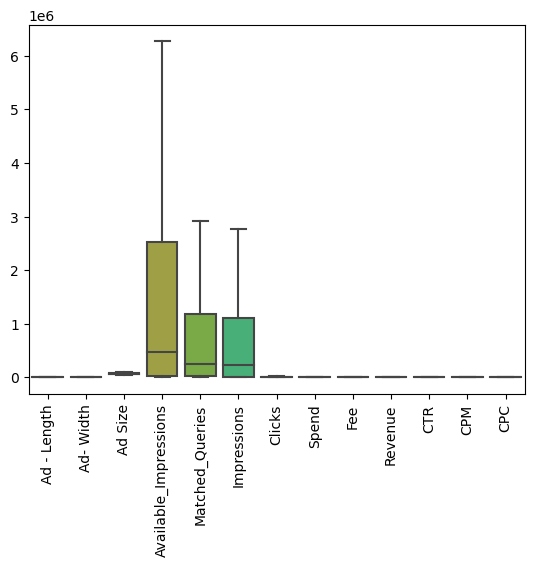

In [116]:
plt.xticks(rotation=90)
sns.boxplot(data=clustering_df_num)

In [117]:
# The count of outliers in each column
((clustering_df_num < (Q1 - 1.5 * IQR)) | (clustering_df_num > (Q3 + 1.5 * IQR))).sum()

Ad - Length              0
Ad- Width                0
Ad Size                  0
Available_Impressions    0
Matched_Queries          0
Impressions              0
Clicks                   0
Spend                    0
Fee                      0
Revenue                  0
CTR                      0
CPM                      0
CPC                      0
dtype: int64

### Scaling Data

In [118]:
clustering_df_num.describe()

,Ad - Length,Ad- Width,Ad Size,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
count,23066.000000,23066.000000,23066.000000,2.306600e+04,2.306600e+04,2.306600e+04,23066.000000,23066.000000,23066.000000,23066.000000,23066.000000,23066.000000,23066.000000
mean,385.163097,337.896037,76576.835169,1.607253e+06,7.995380e+05,7.536120e+05,8306.828194,2166.060098,0.340288,1449.388572,8.223203,8.219181,0.330035
std,233.651434,203.092885,15381.320695,2.125528e+06,1.026037e+06,9.802568e+05,9574.779384,2425.189632,0.018129,1646.893583,8.253522,6.881016,0.316568
min,120.000000,70.000000,54000.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000,0.300000,0.000000,0.010874,0.000000,0.000000
25%,120.000000,250.000000,72000.000000,3.367225e+04,1.828250e+04,7.990500e+03,710.000000,85.180000,0.330000,55.365375,0.265107,1.749084,0.089736
50%,300.000000,300.000000,72000.000000,4.837710e+05,2.580875e+05,2.252900e+05,4425.000000,1425.125000,0.350000,926.335000,9.391248,8.371566,0.139347
75%,720.000000,600.000000,84000.000000,2.527712e+06,1.180700e+06,1.112428e+06,12793.750000,3121.400000,0.350000,2091.338150,13.470571,13.042018,0.546242
max,728.000000,600.000000,102000.000000,6.268771e+06,2.924326e+06,2.769086e+06,30919.375000,7675.730000,0.350000,5145.297312,33.278766,29.981418,1.231002


In [119]:
## Using Zscore for scaling/standardisation
from scipy.stats import zscore
clustering_scaled_df=clustering_df_num.apply(zscore)

In [120]:
clustering_scaled_df.describe()

,Ad - Length,Ad- Width,Ad Size,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
count,2.306600e+04,2.306600e+04,2.306600e+04,2.306600e+04,2.306600e+04,23066.000000,2.306600e+04,2.306600e+04,2.306600e+04,2.306600e+04,2.306600e+04,2.306600e+04,2.306600e+04
mean,1.281478e-16,-1.182903e-16,3.055833e-16,9.857525e-18,1.971505e-17,0.000000,-1.182903e-16,-9.857525e-17,1.143473e-15,3.943010e-17,1.380054e-16,2.464381e-17,3.943010e-17
std,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00
min,-1.134891e+00,-1.319110e+00,-1.467840e+00,-7.561823e-01,-7.792648e-01,-0.768806,-8.674882e-01,-8.931702e-01,-2.222416e+00,-8.800933e-01,-9.950306e-01,-1.194498e+00,-1.042561e+00
25%,-1.134891e+00,-4.327968e-01,-2.975645e-01,-7.403406e-01,-7.614468e-01,-0.760655,-7.934379e-01,-8.580464e-01,-5.675316e-01,-8.464745e-01,-9.642269e-01,-9.403026e-01,-7.590912e-01
50%,-3.644957e-01,-1.865987e-01,-2.975645e-01,-5.285774e-01,-5.277221e-01,-0.538975,-4.054310e-01,-3.055230e-01,5.357244e-01,-3.176070e-01,1.415239e-01,2.214626e-02,-6.023707e-01
75%,1.433093e+00,1.290590e+00,4.826195e-01,4.330590e-01,3.714976e-01,0.366051,4.686290e-01,3.939323e-01,5.357244e-01,3.898027e-01,6.357869e-01,7.009055e-01,6.829874e-01
max,1.467332e+00,1.290590e+00,1.652896e+00,2.193158e+00,2.070914e+00,2.056111,2.361729e+00,2.271900e+00,5.357244e-01,2.244218e+00,3.035808e+00,3.162718e+00,2.846105e+00


### Hierarchical Clustering


#### Construct a dendrogram using Ward linkage and Euclidean distance - Identify the optimum number of Clusters

In [121]:
clustering_df.head()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
0,2020-9-2-17,Format1,300,250,75000,Inter222,Video,Desktop,Display,1806,325,323,1,0.0,0.35,0.0,0.309598,0.0,0.0
1,2020-9-2-10,Format1,300,250,75000,Inter227,App,Mobile,Video,1780,285,285,1,0.0,0.35,0.0,0.350877,0.0,0.0
2,2020-9-1-22,Format1,300,250,75000,Inter222,Video,Desktop,Display,2727,356,355,1,0.0,0.35,0.0,0.281690,0.0,0.0
3,2020-9-3-20,Format1,300,250,75000,Inter228,Video,Mobile,Video,2430,497,495,1,0.0,0.35,0.0,0.202020,0.0,0.0
4,2020-9-4-15,Format1,300,250,75000,Inter217,Web,Desktop,Video,1218,242,242,1,0.0,0.35,0.0,0.413223,0.0,0.0


### Choosing ward linkage method and euclidean distance for metric

In [122]:
link_method = linkage(clustering_scaled_df, method = 'ward',metric='euclidean')

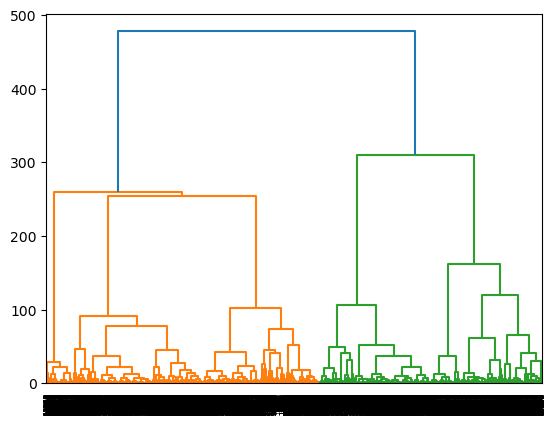

In [123]:
dend = dendrogram(link_method,show_leaf_counts=True)

### Cutting the Dendrogram with suitable clusters

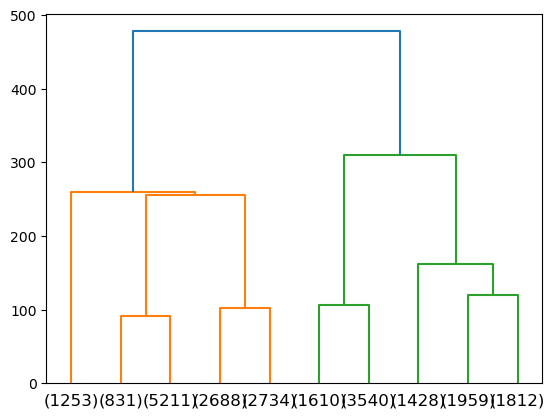

In [123]:
dend = dendrogram(link_method,
                 truncate_mode='lastp',
                 p = 10
                 
                 )

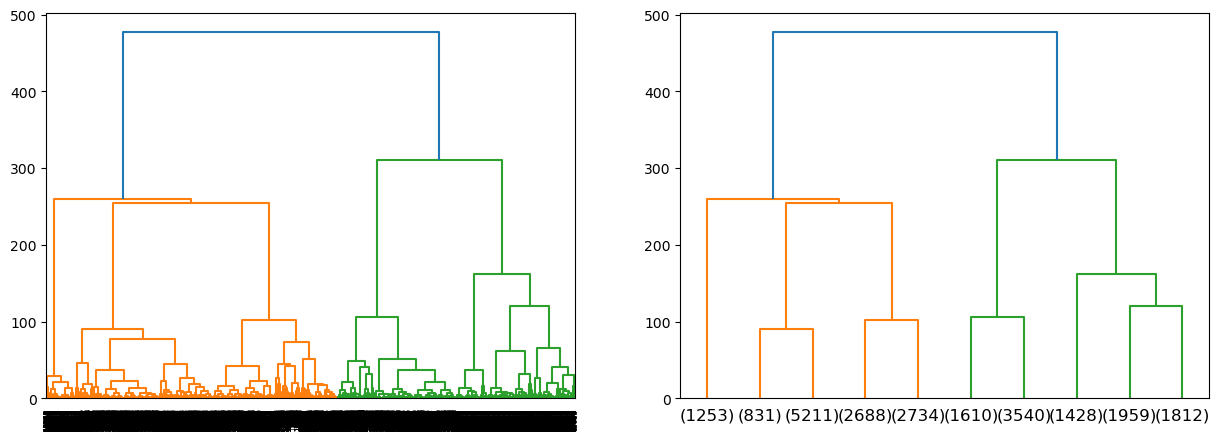

In [125]:
import matplotlib.pyplot as plt
plt.figure(figsize =(15,5))
plt.subplot(1,2,1)
dend1= dendrogram(link_method)
plt.subplot(1,2,2)
dend2 = dendrogram(link_method,
                 truncate_mode='lastp',
                 p = 10
                  
                 )
plt.show()

# Creating Clusters using KMeans

### Forming clusters with K = 1,2,3,4,5,6,7,8,9,10 and comparing the WSS

In [124]:
k_means = KMeans(n_clusters = 1,random_state=1)
k_means.fit(clustering_scaled_df)
k_means.inertia_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


299858.0000000003

In [125]:
k_means = KMeans(n_clusters = 2,random_state=1)
k_means.fit(clustering_scaled_df)
k_means.inertia_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


183349.10202886089

In [126]:
k_means = KMeans(n_clusters = 3,random_state=1)
k_means.fit(clustering_scaled_df)
k_means.inertia_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


130878.35297256609

In [127]:
k_means = KMeans(n_clusters = 4,random_state=1)
k_means.fit(clustering_scaled_df)
k_means.inertia_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


95133.92434119368

In [128]:
k_means = KMeans(n_clusters = 5,random_state=1)
k_means.fit(clustering_scaled_df)
k_means.inertia_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


61539.191032286064

In [129]:
k_means = KMeans(n_clusters = 6,random_state=1)
k_means.fit(clustering_scaled_df)
k_means.inertia_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


51676.89230709958

In [130]:
k_means = KMeans(n_clusters = 7,random_state=1)
k_means.fit(clustering_scaled_df)
k_means.inertia_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


44598.26211613907

In [131]:
k_means = KMeans(n_clusters = 8,random_state=1)
k_means.fit(clustering_scaled_df)
k_means.inertia_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


40712.91330458563

In [132]:
k_means = KMeans(n_clusters = 9,random_state=1)
k_means.fit(clustering_scaled_df)
k_means.inertia_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


36061.70487805706

In [133]:
k_means = KMeans(n_clusters = 10,random_state=1)
k_means.fit(clustering_scaled_df)
k_means.inertia_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


33562.460459679816

WSS reduces as K keeps increasing

### Calculating WSS for other values of K - Elbow Method

In [134]:
wss =[] 

In [135]:
for i in range(1,11):
    KM = KMeans(n_clusters=i,random_state=1)
    KM.fit(clustering_scaled_df)
    wss.append(KM.inertia_)

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

In [136]:
wss

[299858.0000000003,
 183349.10202886086,
 130878.35297256609,
 95133.92434119368,
 61539.191032286064,
 51676.892307099595,
 44598.26211613907,
 40712.91330458563,
 36061.70487805706,
 33562.460459679816]

In [137]:
a=[1,2,3,4,5,6,7,8,9,10]

<Axes: >

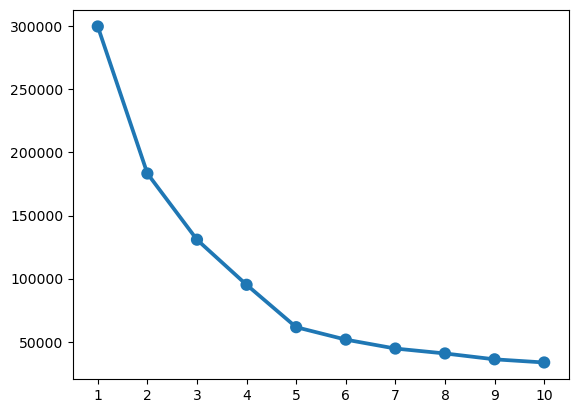

In [138]:
sns.pointplot(x=a, y=wss)

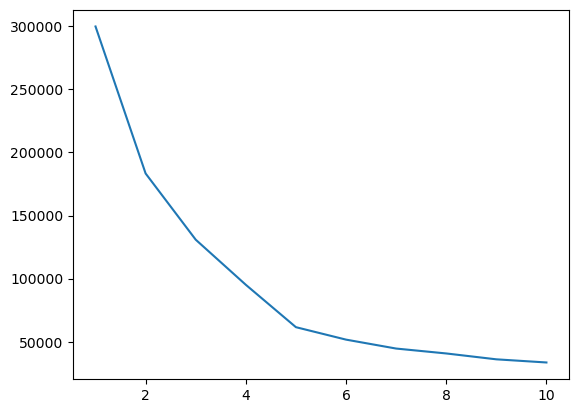

In [139]:
plt.plot(range(1,11), wss)

# KMeans with K=4

In [140]:
k_means = KMeans(n_clusters = 4,random_state=1)
k_means.fit(clustering_scaled_df)
labels = k_means.labels_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


### Cluster evaluation for 4 clusters: the silhouette score

In [141]:
from sklearn.metrics import silhouette_samples, silhouette_score

In [142]:
# Calculating silhouette_score
silhouette_score(clustering_scaled_df,labels,random_state=1)

0.44534519247649795

# KMeans with K=5

In [143]:
k_means = KMeans(n_clusters = 5,random_state=1)
k_means.fit(clustering_scaled_df)
labels = k_means.labels_

C:\Users\Vijay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


### Cluster evaluation for 5 clusters

In [144]:
#from sklearn.metrics import silhouette_samples, silhouette_score

In [145]:
silhouette_score(clustering_scaled_df,labels,random_state=1)

0.5240956940501831

silhouette score is better for 5 clusters than for 4 clusters. So, final clusters will be 5

Appending Clusters to the original dataset

In [146]:
clustering_df["Clus_kmeans5"] = labels
clustering_df.head()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC,Clus_kmeans5
0,2020-9-2-17,Format1,300,250,75000,Inter222,Video,Desktop,Display,1806,325,323,1,0.0,0.35,0.0,0.309598,0.0,0.0,0
1,2020-9-2-10,Format1,300,250,75000,Inter227,App,Mobile,Video,1780,285,285,1,0.0,0.35,0.0,0.350877,0.0,0.0,0
2,2020-9-1-22,Format1,300,250,75000,Inter222,Video,Desktop,Display,2727,356,355,1,0.0,0.35,0.0,0.281690,0.0,0.0,0
3,2020-9-3-20,Format1,300,250,75000,Inter228,Video,Mobile,Video,2430,497,495,1,0.0,0.35,0.0,0.202020,0.0,0.0,0
4,2020-9-4-15,Format1,300,250,75000,Inter217,Web,Desktop,Video,1218,242,242,1,0.0,0.35,0.0,0.413223,0.0,0.0,0


In [147]:
clustering_df_num["Clus_kmeans5"] = labels
clustering_df_num.head()

,Ad - Length,Ad- Width,Ad Size,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC,Clus_kmeans5
0,300,250,75000.0,1806.0,325.0,323.0,1.0,0.0,0.35,0.0,0.309598,0.0,0.0,0
1,300,250,75000.0,1780.0,285.0,285.0,1.0,0.0,0.35,0.0,0.350877,0.0,0.0,0
2,300,250,75000.0,2727.0,356.0,355.0,1.0,0.0,0.35,0.0,0.281690,0.0,0.0,0
3,300,250,75000.0,2430.0,497.0,495.0,1.0,0.0,0.35,0.0,0.202020,0.0,0.0,0
4,300,250,75000.0,1218.0,242.0,242.0,1.0,0.0,0.35,0.0,0.413223,0.0,0.0,0


# Cluster Profiling

In [148]:
clustering_df_num.Clus_kmeans5.value_counts().sort_index()

Clus_kmeans5
0    6275
1    4676
2    6524
3    4054
4    1537
Name: count, dtype: int64

#### Mean based on Clusters

In [149]:

clust_profile=clustering_df_num.groupby('Clus_kmeans5').mean()
clust_profile['freq']=clustering_df_num.Clus_kmeans5.value_counts().sort_index()
clust_profile

,Ad - Length,Ad- Width,Ad Size,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC,freq
Clus_kmeans5,,,,,,,,,,,,,,
0,421.696255,152.001594,64299.996813,1.810314e+06,8.642623e+05,8.262209e+05,3263.131952,1500.090563,0.349264,977.424163,0.404392,1.788731,0.528129,6275
1,683.825492,303.785287,100775.876818,2.513465e+05,1.375509e+05,1.167714e+05,14127.278203,1252.285569,0.349538,815.541831,13.289690,11.728833,0.090012,4676
2,143.280809,572.103004,73966.738197,3.209356e+04,1.962406e+04,1.349204e+04,1914.448804,209.162609,0.349988,135.993379,15.784443,14.330063,0.102764,6524
3,465.781944,199.148989,72963.936852,5.695405e+06,2.806219e+06,2.671268e+06,11245.754810,5739.327617,0.313281,3878.748366,0.217242,1.573280,0.748699,4054
4,141.454782,572.446324,73686.402082,8.063284e+05,5.668641e+05,4.781485e+05,30572.439330,6546.373195,0.305569,4471.776116,13.752664,15.385753,0.111918,1537


#### Median based on Clusters

In [155]:

clust_profile=clustering_df_num.groupby('Clus_kmeans5').median()
#clust_profile['freq']=clustering_df_num.Clus_kmeans5.value_counts().sort_index()
clust_profile

,Ad - Length,Ad- Width,Ad Size,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
Clus_kmeans5,,,,,,,,,,,,,
0,480.0,70.0,54000.0,1833902.0,861001.00,815606.0,3254.000,1548.630,0.35,1006.609500,0.397983,1.817682,0.468738
1,720.0,300.0,102000.0,213610.0,137284.00,115859.0,14723.500,1336.860,0.35,868.955000,12.469471,11.087378,0.090971
2,120.0,600.0,72000.0,13920.5,8263.50,3631.5,454.000,47.460,0.35,30.848000,13.823976,13.381682,0.092500
3,300.0,250.0,75000.0,6268771.0,2924326.25,2769085.5,8928.500,5229.225,0.30,3660.460000,0.224249,1.564732,0.714893
4,120.0,600.0,72000.0,831024.0,583232.00,490310.0,30919.375,7172.600,0.30,5145.297312,13.575089,14.826422,0.111486


In [162]:
clustering_df.head()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC,Clus_kmeans5
0,2020-9-2-17,Format1,300,250,75000,Inter222,Video,Desktop,Display,1806,325,323,1,0.0,0.35,0.0,0.309598,0.0,0.0,0
1,2020-9-2-10,Format1,300,250,75000,Inter227,App,Mobile,Video,1780,285,285,1,0.0,0.35,0.0,0.350877,0.0,0.0,0
2,2020-9-1-22,Format1,300,250,75000,Inter222,Video,Desktop,Display,2727,356,355,1,0.0,0.35,0.0,0.281690,0.0,0.0,0
3,2020-9-3-20,Format1,300,250,75000,Inter228,Video,Mobile,Video,2430,497,495,1,0.0,0.35,0.0,0.202020,0.0,0.0,0
4,2020-9-4-15,Format1,300,250,75000,Inter217,Web,Desktop,Video,1218,242,242,1,0.0,0.35,0.0,0.413223,0.0,0.0,0


<Axes: xlabel='Clus_kmeans5', ylabel='Clicks'>

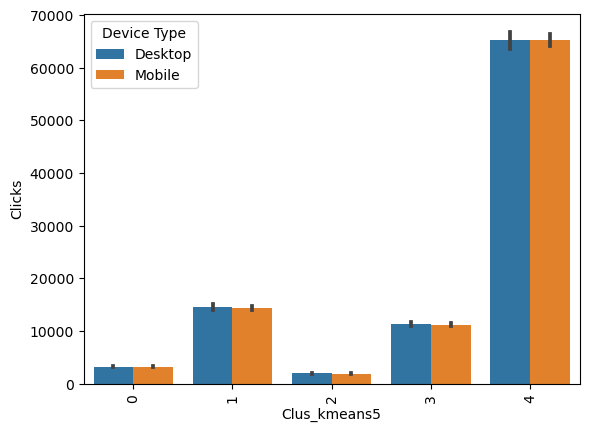

In [179]:
plt.xticks(rotation=90)
sns.barplot(data=clustering_df,x='Clus_kmeans5',y='Clicks',hue='Device Type')

<Axes: xlabel='Clus_kmeans5', ylabel='Spend'>

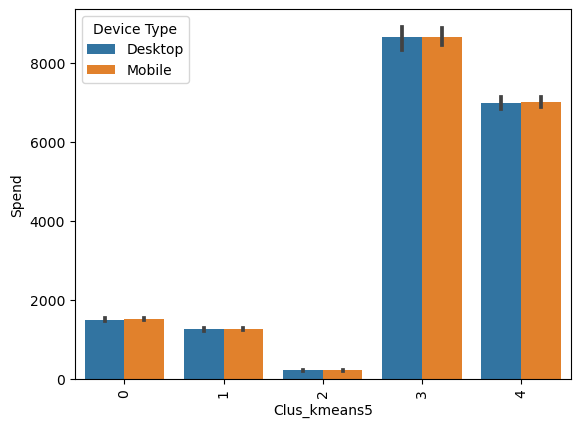

In [180]:

plt.xticks(rotation=90)
sns.barplot(data=clustering_df,x='Clus_kmeans5',y='Spend',hue='Device Type')

<Axes: xlabel='Clus_kmeans5', ylabel='Revenue'>

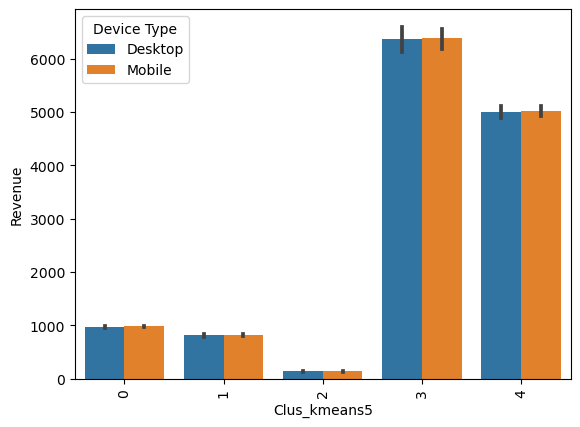

In [181]:
plt.xticks(rotation=90)

sns.barplot(data=clustering_df,x='Clus_kmeans5',y='Revenue',hue='Device Type')

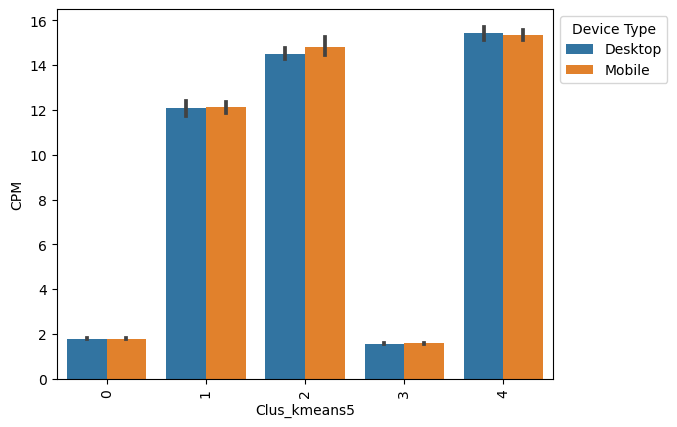

In [182]:

plt.xticks(rotation=90)
ax=sns.barplot(data=clustering_df,x='Clus_kmeans5',y='CPM',hue='Device Type')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


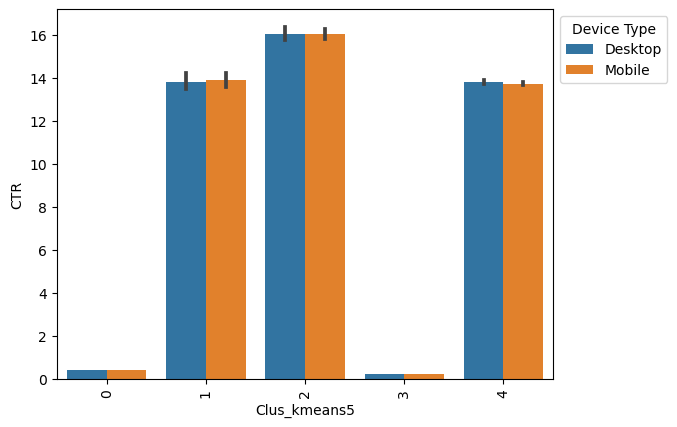

In [183]:
plt.xticks(rotation=90)

ax=sns.barplot(data=clustering_df,x='Clus_kmeans5',y='CTR',hue='Device Type')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

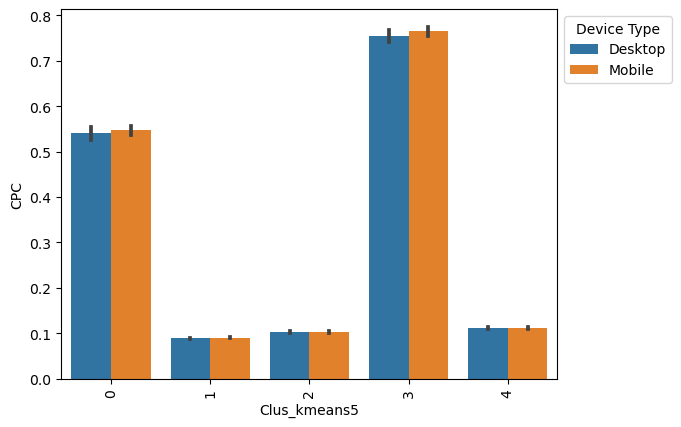

In [184]:
plt.xticks(rotation=90)

ax=sns.barplot(data=clustering_df,x='Clus_kmeans5',y='CPC',hue='Device Type')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))